In [1]:
# Fig3: Dissecting the structural basis of burst and sustained dynamics through domain swapping
# Analysis to identify the three behavioral groups from the paper:
# 1. Slow-sustained: prolonged motion >12 h, velocity 10-50 nm/s
# 2. Fast-burst: brief motion < 2 h, velocity 50-1000 nm/s  
# 3. Multiphase: concentration-dependent transitions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.optimize import curve_fit, least_squares
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

# Keep essential columns for behavioral analysis (removed Translation Rate aa_s as it was faulty)
columns_to_keep = ['time (s)',  'Protein Concentration_nM', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM']
df = df[columns_to_keep]

# Remove rows with missing protein names
df = df.dropna(subset=['protein'])

# Remove proteins that have only NaNs in velocity magnitude column
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")

# Check which proteins have only NaN velocity measurements
velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()

print(f"\nProteins with only NaN velocity measurements: {proteins_with_nan_velocity}")

# Remove these proteins
df = df[~df['protein'].isin(proteins_with_nan_velocity)]

print(f"\nAfter filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")
print(f"Remaining proteins: {df['protein'].unique()}")

# Create unique condition labels for each protein-DNA nM pair
df['protein'] = df['protein'].astype(str) + '-' + df['DNA nM'].astype(str) + 'nM'

# Check data quality
print(f"\nData quality check:")
print(f"Rows with valid velocity data: {df['velocity magnitude [m/s]_mean'].notna().sum()}")
print(f"Rows with valid time data: {df['time (s)'].notna().sum()}")
print(f"Rows with valid protein data: {df['protein'].notna().sum()}")

df

Before filtering:
Total rows: 182000
Unique proteins: 17

Proteins with only NaN velocity measurements: ['B', 'BleSto', 'E', 'F']

After filtering:
Total rows: 177776
Unique proteins: 13
Remaining proteins: ['A' 'H' 'C' 'G' 'D' 'ThTr' 'AcSu2' 'DiPu' 'HeAl' 'NaGr' 'AdPa' 'Unc'
 'Kif5']

Data quality check:
Rows with valid velocity data: 122771
Rows with valid time data: 177776
Rows with valid protein data: 177776


,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,distance [m]_mean,power [W]_mean,work [J]_mean,protein,DNA nM
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-1.25nM,1.25
1,600.0,1.909813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-1.25nM,1.25
2,1200.0,3.075428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-1.25nM,1.25
3,1800.0,4.749361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-1.25nM,1.25
4,2400.0,6.528183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A-1.25nM,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
243916,131220.0,122.844224,7.554028e-08,6.000483e-07,6.008068e-10,1.705629e-07,-1.453127e-07,0.000112,0.000722,5.768031e-23,5.727192e-18,Kif5-160.0nM,160.00
243917,131265.0,122.777871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.00
243918,131310.0,122.759158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.00
243919,131355.0,122.815775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.00


## DNA concentration selection (optional)
Set the DNA concentrations to include in the analysis. Leave as `None` to include all concentrations available in the dataset. Example: `[5.0, 10.0, 20.0, 40.0]` (units nM).


In [3]:
# User-configurable: which DNA concentrations to include (nM). None = include all.
include_dna_nM = [None]  # e.g., [5.0, 10.0, 20.0, 40.0]

# Apply selection early so all downstream analyses respect it
if include_dna_nM is not None:
    try:
        include_set = set([float(x) for x in include_dna_nM])
        df = df[df['DNA nM'].isin(include_set)].copy()
        print(f"Filtering to DNA concentrations: {sorted(include_set)} nM")
        print(f"New dataset shape: {df.shape}; unique conditions: {df['protein'].nunique()}")
    except Exception as e:
        print(f"DNA selection ignored due to error: {e}")
else:
    print("Including all DNA concentrations.")


DNA selection ignored due to error: float() argument must be a string or a real number, not 'NoneType'


In [4]:
# Motor Protein Behavioral Classification Analysis
# Objective: Classify motor proteins into behavioral groups using unsupervised ML

print("=== Motor Protein Behavioral Classification Analysis ===")
print(f"Dataset shape: {df.shape}")
print(f"Unique conditions: {df['protein'].nunique()}")
print(f"Time range: {df['time (s)'].min():.1f} - {df['time (s)'].max():.1f} seconds")
print(f"Proteins: {sorted(df['protein'].str.split('-').str[0].unique())}")
print(f"DNA concentrations: {sorted(df['DNA nM'].unique())} nM")


=== Motor Protein Behavioral Classification Analysis ===
Dataset shape: (177776, 13)
Unique conditions: 95
Time range: 0.0 - 156600.0 seconds
Proteins: ['A', 'AcSu2', 'AdPa', 'C', 'D', 'DiPu', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr', 'Unc']
DNA concentrations: [1.25, 2.5, 5.0, 8.0, 10.0, 20.0, 40.0, 80.0, 85.0, 160.0] nM


## Velocity vs time per protein (annotated), one subplot each
Reproduces the style from the other notebook: markers, per‑DNA trajectories, annotated last points with `protein‑DNAnM`, auto axis limits, legends only if data exist.



VELOCITY vs TIME PLOTS FOR EACH PROTEIN (ANNOTATED)
Proteins: ['A', 'AcSu2', 'AdPa', 'C', 'D', 'DiPu', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr', 'Unc']
DNA concentrations: [1.25, 2.5, 5.0, 8.0, 10.0, 20.0, 40.0, 80.0, 85.0, 160.0]

Processing protein A: 4130 rows

Processing protein AcSu2: 7112 rows

Processing protein AdPa: 29816 rows

Processing protein C: 9466 rows

Processing protein D: 5277 rows

Processing protein DiPu: 1320 rows

Processing protein G: 11872 rows

Processing protein H: 4230 rows

Processing protein HeAl: 7048 rows

Processing protein Kif5: 2921 rows

Processing protein NaGr: 30840 rows

Processing protein ThTr: 59420 rows

Processing protein Unc: 4324 rows


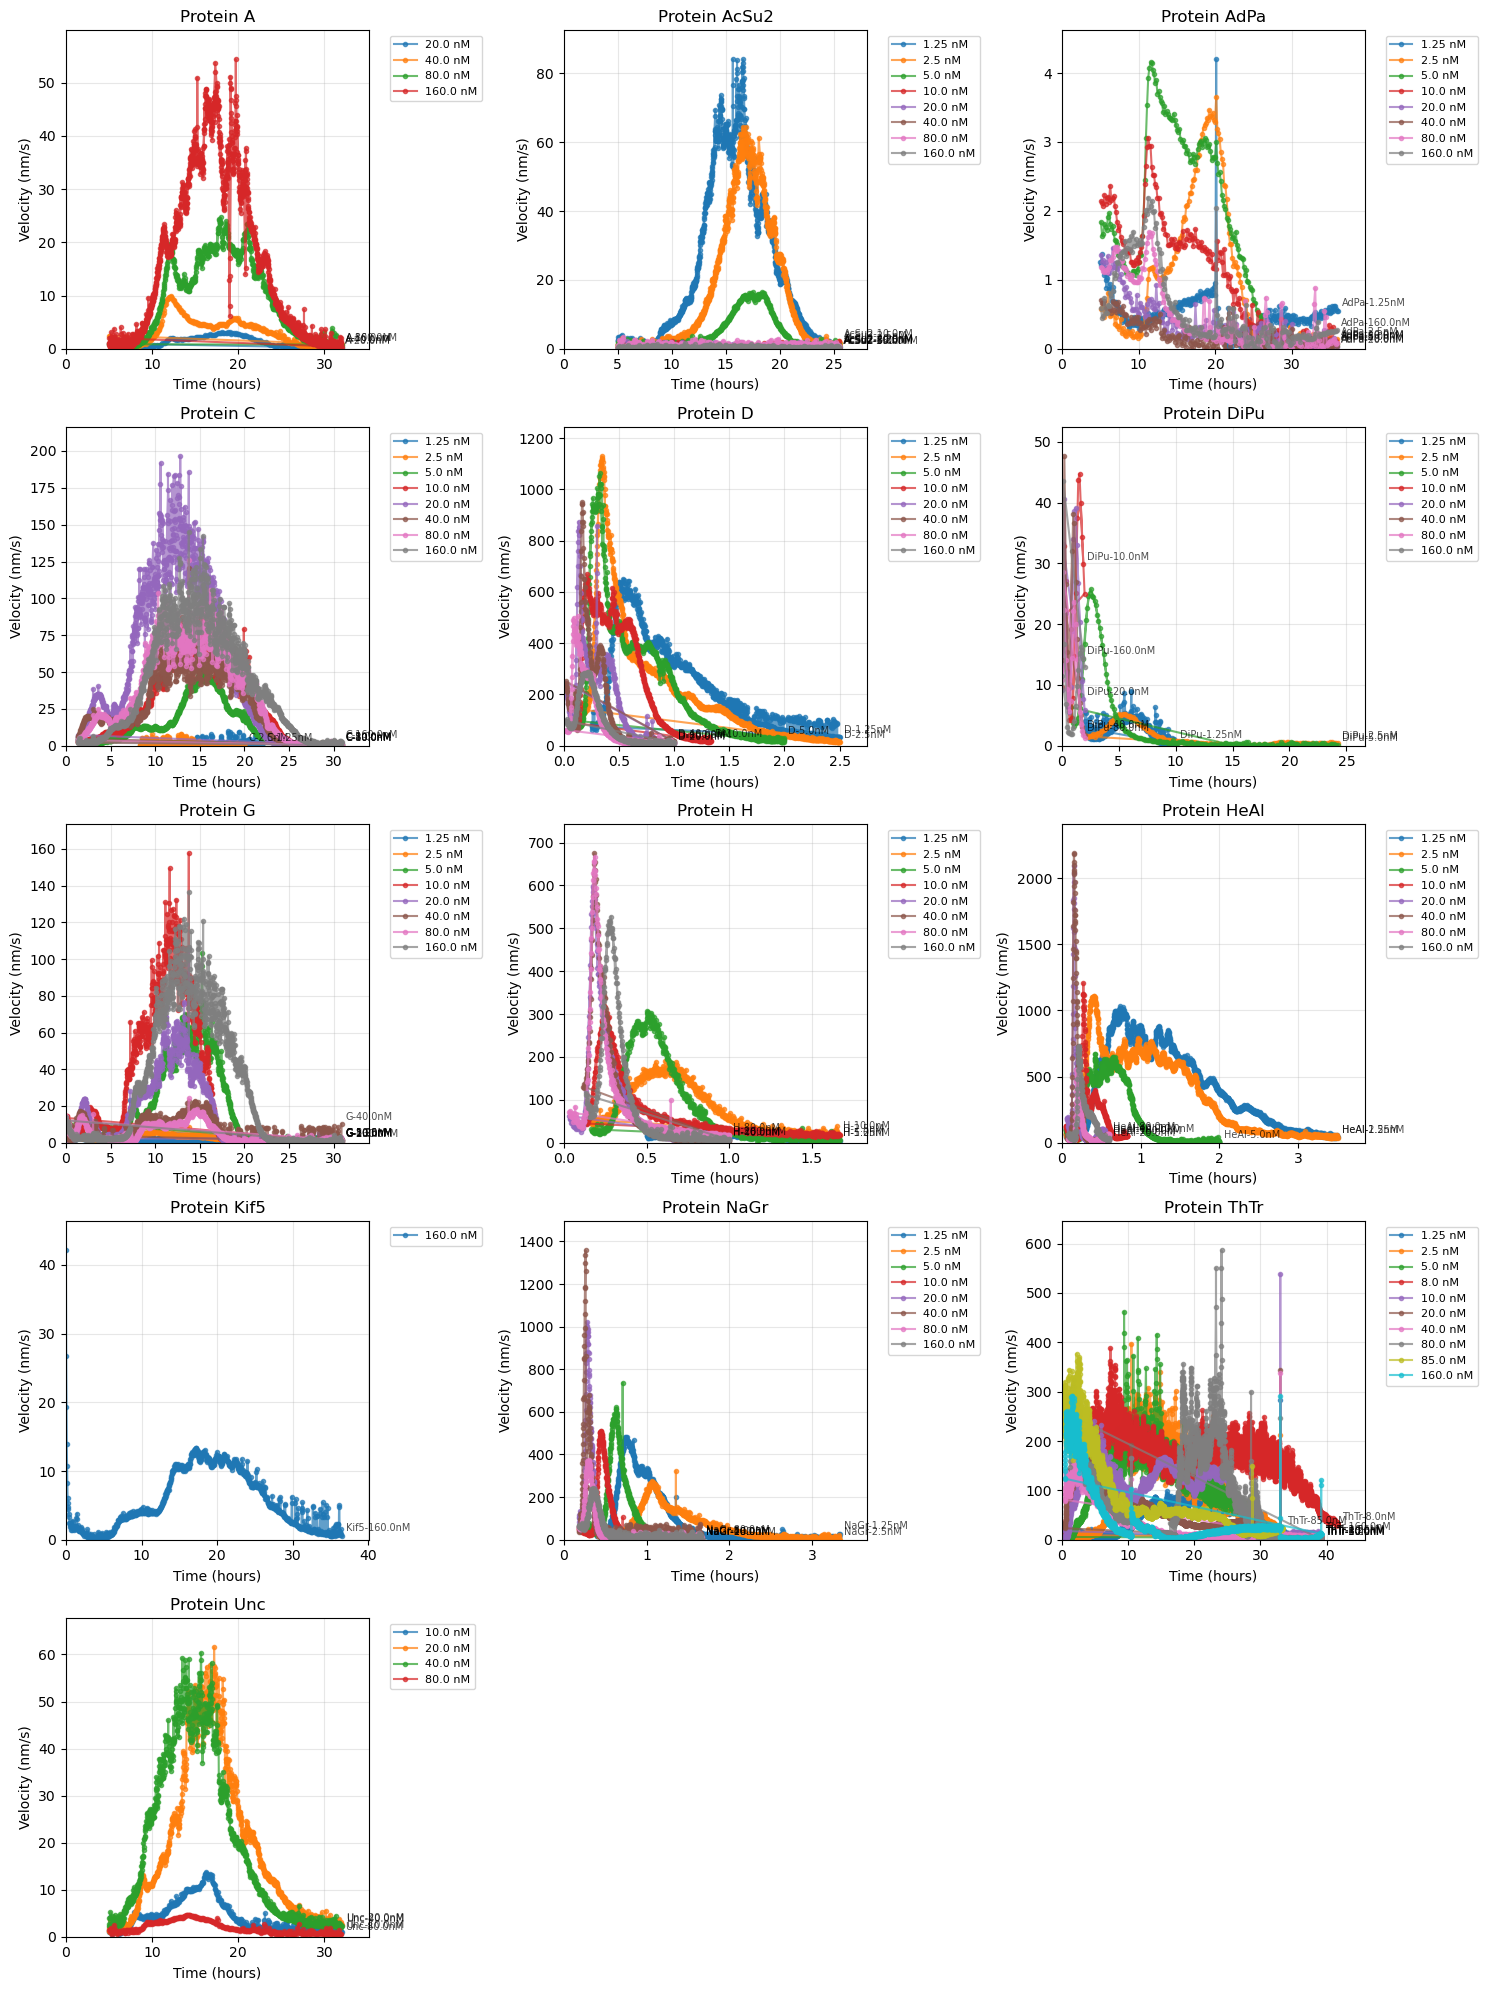


Plotting complete for 13 proteins


In [5]:
# Per-protein velocity vs time (annotated), adapted
print("\n" + "="*80)
print("VELOCITY vs TIME PLOTS FOR EACH PROTEIN (ANNOTATED)")
print("="*80)

# Get proteins and DNA concentrations present after any filtering
proteins = sorted([p for p in df['protein'].str.split('-').str[0].unique() if pd.notna(p)])
dna_concentrations = sorted([d for d in df['DNA nM'].unique() if pd.notna(d)])

print(f"Proteins: {proteins}")
print(f"DNA concentrations: {dna_concentrations}")

n_proteins = len(proteins)
n_cols = 3
n_rows = (n_proteins + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_rows == 1 and n_cols > 1:
    axes = axes.reshape(1, -1)
axes = np.array(axes).flatten()

for i, protein in enumerate(proteins):
    ax = axes[i]
    protein_data = df[df['protein'].str.startswith(protein + '-')]
    print(f"\nProcessing protein {protein}: {len(protein_data)} rows")
    
    plotted_any = False
    for dna_conc in dna_concentrations:
        conc_data = protein_data[protein_data['DNA nM'] == dna_conc]
        if not conc_data.empty:
            time_hours = conc_data['time (s)'] / 3600
            velocity_nm_s = conc_data['velocity magnitude [m/s]_mean'] * 1e9
            valid_mask = ~velocity_nm_s.isna() & ~time_hours.isna()
            if valid_mask.any():
                ax.plot(time_hours[valid_mask], velocity_nm_s[valid_mask], 
                        marker='o', markersize=3, alpha=0.7, 
                        label=f'{dna_conc} nM', linewidth=1.5)
                plotted_any = True
                # annotate last valid point
                last_idx = np.where(valid_mask)[0][-1]
                ax.annotate(f"{protein}-{dna_conc}nM",
                            (time_hours.iloc[last_idx], velocity_nm_s.iloc[last_idx]),
                            xytext=(3,3), textcoords='offset points', fontsize=7, alpha=0.7)
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Velocity (nm/s)')
    ax.set_title(f'Protein {protein}')
    ax.grid(True, alpha=0.3)
    
    if plotted_any:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        valid_data = protein_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
        if not valid_data.empty:
            max_time = valid_data['time (s)'].max() / 3600
            max_vel = valid_data['velocity magnitude [m/s]_mean'].max() * 1e9
            if np.isfinite(max_time) and np.isfinite(max_vel):
                ax.set_xlim(0, max_time * 1.1)
                ax.set_ylim(0, max_vel * 1.1)
    else:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, alpha=0.5)

# Hide unused subplots
for i in range(n_proteins, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nPlotting complete for {n_proteins} proteins")


## Alternative exploratory plots: per-protein velocity vs time with annotated conditions
This alternative view mirrors your preferred style: one subplot per protein, each DNA concentration as a separate trajectory, with the last valid point annotated by the `protein-DNAnM` label. Axes automatically scale to each protein's data range; legends are included only when data are present.


## Exploratory view: velocity vs time per motor (DNA overlaid)
This grid provides a quick sanity check and intuition: one subplot per motor (base protein name), with velocity time series overlaid for all DNA concentrations. Colors encode DNA levels; curves optionally smoothed for readability. Use this to spot concentration-dependent shifts before feature engineering.


In [6]:
# # Enforce global drop of shear/strain from condition-level analysis
# # Apply after feature engineering and before PCA prep
# feature_df = feature_df.drop(columns=['shear_mean', 'strain_mean', 'shear [1/s]_mean', 'strain [1/s]_mean'], errors='ignore')
# if 'feature_columns' in locals():
#     feature_columns = [c for c in feature_columns if c not in ['shear_mean', 'strain_mean']]
# print('Shear/strain removed. Columns now in feature_df:', [c for c in feature_df.columns if ('shear' in c or 'strain' in c)])


In [7]:
# Feature Engineering: Create condition-level summaries and behavioral features

def engineer_features(df):
    """
    Engineer temporal and behavioral features for each condition
    """
    results = []
    
    for condition in df['protein'].unique():
        try:
            condition_data = df[df['protein'] == condition].copy()
            condition_data = condition_data.sort_values('time (s)')
        except Exception as e:
            print(f"Error processing condition {condition}: {e}")
            continue
        
        # Basic info
        protein_name = condition.split('-')[0]
        dna_concentration = condition_data['DNA nM'].iloc[0]
        
        # Initialize default values
        max_velocity = 0
        mean_velocity = 0
        time_to_max_velocity = 0
        activation_onset = 0
        duration_high_velocity = 0
        max_translation_rate = 0
        time_to_max_translation = 0
        correlation_length_at_vmax = 0
        vorticity_mean_smoothed = 0
        divergence_mean_smoothed = 0
        shear_mean = 0
        strain_mean = 0
        work_max = 0
        n_measurements = 0
        
        # Velocity analysis
        try:
            velocity = condition_data['velocity magnitude [m/s]_mean'].dropna()
            if len(velocity) == 0:
                print(f"Warning: No velocity data for condition {condition}")
                continue
                
            max_velocity = velocity.max()
            mean_velocity = velocity.mean()
            n_measurements = len(velocity)
        except Exception as e:
            print(f"Error in velocity analysis for {condition}: {e}")
            continue
        
        # Time to max velocity
        try:
            max_velocity_idx = velocity.idxmax()
            time_to_max_velocity = condition_data.loc[max_velocity_idx, 'time (s)'] / 3600  # hours
            
            # Activation onset (20% of max velocity)
            activation_threshold = 0.2 * max_velocity
            above_threshold = velocity >= activation_threshold
            if above_threshold.any():
                activation_onset = condition_data.loc[above_threshold.idxmax(), 'time (s)'] / 3600
            else:
                activation_onset = 0
                
            # Duration at high velocity (≥20% of max)
            if above_threshold.any():
                duration_high_velocity = (condition_data.loc[above_threshold.idxmax():, 'time (s)'].max() - 
                                        condition_data.loc[above_threshold.idxmax(), 'time (s)']) / 3600
            else:
                duration_high_velocity = 0
        except Exception as e:
            print(f"Error in time calculations for {condition}: {e}")
            # Keep default values
            
        # Translation rate (derivative of protein concentration)
        try:
            protein_conc = condition_data['Protein Concentration_nM'].dropna()
            if len(protein_conc) > 1:
                time_points = condition_data.loc[protein_conc.index, 'time (s)']
                translation_rate = np.gradient(protein_conc, time_points)
                max_translation_rate = np.max(translation_rate)
                # Fix: Use iloc instead of direct indexing to avoid KeyError
                max_idx = np.argmax(translation_rate)
                time_to_max_translation = time_points.iloc[max_idx] / 3600
            else:
                max_translation_rate = 0
                time_to_max_translation = 0
        except Exception as e:
            print(f"Error in translation rate calculation for {condition}: {e}")
            max_translation_rate = 0
            time_to_max_translation = 0
            
        # Correlation length at max velocity
        correlation_length = condition_data['correlation length [m]_mean'].dropna()
        max_velocity_idx = velocity.idxmax()
        if len(correlation_length) > 0 and max_velocity_idx in correlation_length.index:
            correlation_length_at_vmax = correlation_length.loc[max_velocity_idx]
        else:
            correlation_length_at_vmax = correlation_length.mean() if len(correlation_length) > 0 else 0
            
        # Smoothed vorticity and divergence (Gaussian filter, σ=10)
        vorticity = condition_data['vorticity [1/s]_mean'].dropna()
        divergence = condition_data['divergence [1/s]_mean'].dropna()
        
        if len(vorticity) > 10:
            try:
                vorticity_smoothed = gaussian_filter1d(vorticity, sigma=10)
                vorticity_mean_smoothed = np.mean(vorticity_smoothed)
            except:
                vorticity_mean_smoothed = vorticity.mean() if len(vorticity) > 0 else 0
        else:
            vorticity_mean_smoothed = vorticity.mean() if len(vorticity) > 0 else 0
            
        if len(divergence) > 10:
            try:
                divergence_smoothed = gaussian_filter1d(divergence, sigma=10)
                divergence_mean_smoothed = np.mean(divergence_smoothed)
            except:
                divergence_mean_smoothed = divergence.mean() if len(divergence) > 0 else 0
        else:
            divergence_mean_smoothed = divergence.mean() if len(divergence) > 0 else 0
            
        # Other features
        try:
            shear_mean = condition_data['shear [1/s]_mean'].mean()
            strain_mean = condition_data['strain [1/s]_mean'].mean()
            work_max = condition_data['work [J]_mean'].max() if not condition_data['work [J]_mean'].isna().all() else 0
        except Exception as e:
            print(f"Error in other features calculation for {condition}: {e}")
            # Keep default values
        
        # Append results
        try:
            results.append({
                'condition_id': condition,
                'protein_name': protein_name,
                'dna_concentration': dna_concentration,
                'velocity_magnitude_max': max_velocity,
                'velocity_magnitude_mean': mean_velocity,
                'vorticity_mean_smoothed': vorticity_mean_smoothed,
                'shear_mean': shear_mean,
                'strain_mean': strain_mean,
                'divergence_mean_smoothed': divergence_mean_smoothed,
                'correlation_length_at_vmax': correlation_length_at_vmax,
                'work_max': work_max,
                'time_to_max_velocity_hours': time_to_max_velocity,
                'activation_onset_hours': activation_onset,
                'duration_high_velocity_hours': duration_high_velocity,
                'max_translation_rate': max_translation_rate,
                'time_to_max_translation_hours': time_to_max_translation,
                'n_measurements': n_measurements
            })
        except Exception as e:
            print(f"Error appending results for {condition}: {e}")
            continue
    
    return pd.DataFrame(results)

# Engineer features
feature_df = engineer_features(df)
print(f"\nFeature engineering completed:")
print(f"Conditions processed: {len(feature_df)}")
print(f"Features per condition: {len(feature_df.columns) - 3}")  # Excluding condition_id, protein_name, dna_concentration
print(f"\nFeature summary:")
print(feature_df.describe())



Feature engineering completed:
Conditions processed: 91
Features per condition: 14

Feature summary:
       dna_concentration  velocity_magnitude_max  velocity_magnitude_mean  \
count          91.000000            9.100000e+01             9.100000e+01   
mean           42.752747            3.311481e-07             6.234277e-08   
std            52.745464            4.396073e-07             8.204673e-08   
min             1.250000            7.063374e-10             2.023779e-10   
25%             5.000000            1.961670e-08             3.729755e-09   
50%            20.000000            1.257844e-07             2.786448e-08   
75%            80.000000            5.186079e-07             8.590573e-08   
max           160.000000            2.187885e-06             4.018298e-07   

       vorticity_mean_smoothed    shear_mean   strain_mean  \
count             9.100000e+01  9.100000e+01  9.100000e+01   
mean              2.259388e-06 -3.146560e-07  1.671599e-06   
std               

In [8]:
# Prepare features for PCA and clustering
# Select the 11 key features as specified in the analysis requirements

feature_columns = [
    'velocity_magnitude_max',           # peak velocity
    'vorticity_mean_smoothed',         # Gaussian filtered vorticity
    'shear_mean',                      # average shear
    'strain_mean',                     # average strain
    'divergence_mean_smoothed',        # Gaussian filtered divergence
    'correlation_length_at_vmax',      # at max velocity
    'work_max',                        # peak work
    'time_to_max_velocity_hours',     # time to peak
    'activation_onset_hours',         # 20% threshold time
    'duration_high_velocity_hours',   # sustained high velocity
    'dna_concentration'                # concentration as feature
]

# Create feature matrix
X = feature_df[feature_columns].copy()

# Handle missing values
print(f"Missing values per feature:")
print(X.isnull().sum())

# Fill missing values with median for each feature
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

print(f"\nAfter handling missing values:")
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns, index=feature_df['condition_id'])

print(f"\nStandardized features:")
print(f"Mean: {X_scaled_df.mean().round(3).to_dict()}")
print(f"Std: {X_scaled_df.std().round(3).to_dict()}")


Missing values per feature:
velocity_magnitude_max          0
vorticity_mean_smoothed         0
shear_mean                      0
strain_mean                     0
divergence_mean_smoothed        0
correlation_length_at_vmax      0
work_max                        0
time_to_max_velocity_hours      0
activation_onset_hours          0
duration_high_velocity_hours    0
dna_concentration               0
dtype: int64

After handling missing values:
Feature matrix shape: (91, 11)
Missing values: 0

Standardized features:
Mean: {'velocity_magnitude_max': -0.0, 'vorticity_mean_smoothed': 0.0, 'shear_mean': 0.0, 'strain_mean': -0.0, 'divergence_mean_smoothed': -0.0, 'correlation_length_at_vmax': -0.0, 'work_max': -0.0, 'time_to_max_velocity_hours': 0.0, 'activation_onset_hours': 0.0, 'duration_high_velocity_hours': 0.0, 'dna_concentration': 0.0}
Std: {'velocity_magnitude_max': 1.006, 'vorticity_mean_smoothed': 1.006, 'shear_mean': 1.006, 'strain_mean': 1.006, 'divergence_mean_smoothed': 1.006, '

In [9]:
# PCA Analysis with 95% variance threshold
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"PCA Analysis:")
print(f"Total components: {len(pca.explained_variance_ratio_)}")
print(f"Components explaining 95% variance: {n_components_95}")
print(f"Variance explained by first {n_components_95} components: {cumulative_variance[n_components_95-1]:.3f}")

# Create PCA dataframe with condition labels
pca_df = pd.DataFrame(
    X_pca[:, :n_components_95], 
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=feature_df['condition_id']
)

print(f"\nPCA components (first {n_components_95}):")
print(pca_df.head())

# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_[:n_components_95].T,
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=feature_columns
)

print(f"\nFeature loadings:")
print(loadings_df.round(3))


PCA Analysis:
Total components: 11
Components explaining 95% variance: 9
Variance explained by first 9 components: 0.969

PCA components (first 9):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
condition_id                                                               
A-20.0nM     -1.161647 -0.360776  0.214099 -0.354509 -1.667586  0.847705   
A-40.0nM     -0.973581 -0.604045  0.261533 -0.265813 -1.136886  0.814463   
A-80.0nM     -2.030101  0.378119  0.635730  0.850957 -0.010132 -0.813114   
A-160.0nM    -1.982028  0.027909  1.020577  1.707194  0.452174 -0.011233   
H-1.25nM      0.355049 -1.105143 -0.794217 -0.094621  0.316523 -1.208712   

                   PC7       PC8       PC9  
condition_id                                
A-20.0nM     -0.952591  0.333687  0.176686  
A-40.0nM     -0.810023  0.403396  0.354090  
A-80.0nM      0.050638  0.848260  0.102396  
A-160.0nM    -0.485659  1.607777  0.223582  
H-1.25nM      0.892957 -1.214955  0.700134  

Fea

In [10]:
# K-means Clustering with optimal k determination
# Test different k values and use silhouette score to find optimal k

# Ensure we have enough data points for clustering
if len(pca_df) < 4:
    print("Warning: Not enough data points for meaningful clustering")
    optimal_k = 2
    kmeans_labels = np.zeros(len(pca_df))
    silhouette_scores = [0]
else:
    k_range = range(2, min(8, len(pca_df) // 2))  # Test k from 2 to 7
    silhouette_scores = []

    for k in k_range:
        try:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            cluster_labels = kmeans.fit_predict(pca_df)
            silhouette_avg = silhouette_score(pca_df, cluster_labels)
            silhouette_scores.append(silhouette_avg)
            print(f"k={k}: Silhouette score = {silhouette_avg:.3f}")
        except Exception as e:
            print(f"k={k}: Error - {e}")
            silhouette_scores.append(0)

    # Find optimal k
    if len(silhouette_scores) > 0 and max(silhouette_scores) > 0:
        optimal_k = k_range[np.argmax(silhouette_scores)]
        print(f"\nOptimal k: {optimal_k} (silhouette score: {max(silhouette_scores):.3f})")
        
        # Final K-means clustering with optimal k
        kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        kmeans_labels = kmeans_final.fit_predict(pca_df)
    else:
        print("Warning: Could not determine optimal k, using k=2")
        optimal_k = 2
        kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
        kmeans_labels = kmeans_final.fit_predict(pca_df)

# Add cluster labels to feature dataframe
feature_df['kmeans_cluster'] = kmeans_labels

print(f"\nK-means clustering results:")
print(f"Cluster distribution:")
print(feature_df['kmeans_cluster'].value_counts().sort_index())

# Show conditions in each cluster
for cluster in sorted(feature_df['kmeans_cluster'].unique()):
    cluster_conditions = feature_df[feature_df['kmeans_cluster'] == cluster]['condition_id'].tolist()
    print(f"\nCluster {cluster}: {cluster_conditions}")


k=2: Silhouette score = 0.251
k=3: Silhouette score = 0.252
k=4: Silhouette score = 0.250
k=5: Silhouette score = 0.247
k=6: Silhouette score = 0.192
k=7: Silhouette score = 0.216

Optimal k: 3 (silhouette score: 0.252)

K-means clustering results:
Cluster distribution:
kmeans_cluster
0    52
1     1
2    38
Name: count, dtype: int64

Cluster 0: ['A-20.0nM', 'A-40.0nM', 'A-80.0nM', 'A-160.0nM', 'C-1.25nM', 'C-2.5nM', 'C-5.0nM', 'C-10.0nM', 'C-20.0nM', 'C-40.0nM', 'C-80.0nM', 'C-160.0nM', 'G-1.25nM', 'G-2.5nM', 'G-5.0nM', 'G-10.0nM', 'G-20.0nM', 'G-40.0nM', 'G-80.0nM', 'G-160.0nM', 'ThTr-1.25nM', 'ThTr-2.5nM', 'ThTr-5.0nM', 'ThTr-10.0nM', 'ThTr-20.0nM', 'ThTr-40.0nM', 'ThTr-80.0nM', 'ThTr-160.0nM', 'AcSu2-1.25nM', 'AcSu2-2.5nM', 'AcSu2-5.0nM', 'AcSu2-10.0nM', 'AcSu2-20.0nM', 'AcSu2-40.0nM', 'AcSu2-80.0nM', 'AcSu2-160.0nM', 'DiPu-2.5nM', 'AdPa-10.0nM', 'AdPa-160.0nM', 'AdPa-1.25nM', 'AdPa-20.0nM', 'AdPa-2.5nM', 'AdPa-40.0nM', 'AdPa-5.0nM', 'AdPa-80.0nM', 'ThTr-85.0nM', 'ThTr-8.0nM', 'Unc

## Saturation analysis: max velocity vs DNA concentration (Michaelis–Menten / Hill)
Rationale: If DNA acts as an activator or limiter of motor-driven dynamics, the peak velocity per condition should increase with DNA and saturate. We fit per-motor curves:

- Michaelis–Menten (MM): \(v(c) = V_{\max} \cdot c / (K_m + c)\)
- Hill (cooperative): \(v(c) = V_{\max} \cdot c^n / (K_m^n + c^n)\)

Procedure:
- Build per-motor datasets from `feature_df`: \(c =\) `dna_concentration`, \(v =\) `velocity_magnitude_max`.
- Fit MM and Hill by non-linear least squares; pick model with lower AIC.
- Report parameters with 95% CI and R²; plot scatter + best-fit curve (nm/s for readability).

Interpretation: `Vmax` encodes asymptotic speed scale; `Km` encodes the DNA concentration at half-max response; `n` captures apparent cooperativity.


## Apparent kinetic parameters (Km, kcat, kcat/Km)
We convert the fitted saturation parameters into interpretable kinetics:

- Km (nM): DNA concentration at half-max response (from MM/Hill best model).
- Apparent kcat (s⁻¹): requires a mapping from peak velocity to catalytic turnovers. We assume a motor step size of 8 nm per catalytic cycle (typical kinesin-like), so `kcat_app ≈ Vmax_nm_s / step_size_nm`.
- Catalytic efficiency: `kcat_app / Km` (reported in s⁻¹·µM⁻¹).

Assumptions and caveats:
- Velocity is a coarse proxy for catalytic throughput; this yields apparent, not absolute, kcat.
- If you have motor-specific step sizes, set them in the step-size mapping below.
- Hill fits report Km as the half-saturation parameter in the chosen parameterization.


In [11]:
# Hierarchical Clustering with natural-k selection
# Ward linkage on PCA space
linkage_matrix = linkage(pca_df, method='ward')

# Search k by silhouette (natural clusters)
h_sil_scores = {}
for k in range(2, min(12, max(3, len(pca_df)//2))):
    labels_k = fcluster(linkage_matrix, t=k, criterion='maxclust')
    try:
        h_sil_scores[k] = silhouette_score(pca_df, labels_k)
    except Exception:
        h_sil_scores[k] = -1

best_h_k = max(h_sil_scores, key=h_sil_scores.get)
hierarchical_labels = fcluster(linkage_matrix, t=best_h_k, criterion='maxclust')
feature_df['hierarchical_cluster'] = hierarchical_labels

# Agreement with K-means
if 'kmeans_cluster' in feature_df.columns:
    ari_score = adjusted_rand_score(feature_df['kmeans_cluster'], feature_df['hierarchical_cluster'])
else:
    ari_score = np.nan

print(f"Hierarchical clustering results (natural k):")
print(f"Best k by silhouette: {best_h_k} (score={h_sil_scores[best_h_k]:.3f}), ARI vs K-means: {ari_score:.3f}")
print(f"Cluster distribution:")
print(feature_df['hierarchical_cluster'].value_counts().sort_index())

# Show conditions in each hierarchical cluster
for cluster in sorted(feature_df['hierarchical_cluster'].unique()):
    cluster_conditions = feature_df[feature_df['hierarchical_cluster'] == cluster]['condition_id'].tolist()
    print(f"\nHierarchical Cluster {cluster}: {cluster_conditions}")

# Compare K-means and Hierarchical clustering
print(f"\nClustering comparison:")
comparison_df = feature_df[['condition_id', 'protein_name', 'dna_concentration', 
                           'kmeans_cluster', 'hierarchical_cluster']].copy()
print(comparison_df)


Hierarchical clustering results (natural k):
Best k by silhouette: 5 (score=0.267), ARI vs K-means: 0.788
Cluster distribution:
hierarchical_cluster
1     3
2    52
3    34
4     1
5     1
Name: count, dtype: int64

Hierarchical Cluster 1: ['ThTr-2.5nM', 'ThTr-5.0nM', 'ThTr-8.0nM']

Hierarchical Cluster 2: ['A-20.0nM', 'A-40.0nM', 'A-80.0nM', 'A-160.0nM', 'C-1.25nM', 'C-2.5nM', 'C-5.0nM', 'C-10.0nM', 'C-20.0nM', 'C-40.0nM', 'C-80.0nM', 'C-160.0nM', 'G-1.25nM', 'G-2.5nM', 'G-5.0nM', 'G-10.0nM', 'G-20.0nM', 'G-40.0nM', 'G-80.0nM', 'G-160.0nM', 'ThTr-1.25nM', 'ThTr-10.0nM', 'ThTr-20.0nM', 'ThTr-40.0nM', 'ThTr-80.0nM', 'ThTr-160.0nM', 'AcSu2-1.25nM', 'AcSu2-2.5nM', 'AcSu2-5.0nM', 'AcSu2-10.0nM', 'AcSu2-20.0nM', 'AcSu2-40.0nM', 'AcSu2-80.0nM', 'AcSu2-160.0nM', 'DiPu-1.25nM', 'DiPu-2.5nM', 'DiPu-5.0nM', 'DiPu-10.0nM', 'AdPa-10.0nM', 'AdPa-160.0nM', 'AdPa-1.25nM', 'AdPa-20.0nM', 'AdPa-2.5nM', 'AdPa-40.0nM', 'AdPa-5.0nM', 'AdPa-80.0nM', 'ThTr-85.0nM', 'Unc-10.0nM', 'Unc-20.0nM', 'Unc-40.0nM', 

Feature contributions to principal components:

Top contributing features to PC1:
  velocity_magnitude_max: 0.4676
  time_to_max_velocity_hours: 0.4028
  duration_high_velocity_hours: 0.3928
  activation_onset_hours: 0.3672
  divergence_mean_smoothed: 0.3631

Top contributing features to PC2:
  work_max: 0.5190
  divergence_mean_smoothed: 0.4255
  time_to_max_velocity_hours: 0.3590
  duration_high_velocity_hours: 0.3371
  correlation_length_at_vmax: 0.3095

Top contributing features to PC3:
  shear_mean: 0.7853
  divergence_mean_smoothed: 0.3490
  work_max: 0.3251
  dna_concentration: 0.2549
  strain_mean: 0.1656

Full loadings matrix (first 5 components):
                                 PC1     PC2     PC3     PC4     PC5
velocity_magnitude_max        0.4676  0.2530 -0.1364  0.0413  0.0255
vorticity_mean_smoothed       0.1916  0.1133 -0.1258  0.5163 -0.3506
shear_mean                    0.0101  0.0267  0.7853 -0.3033  0.0128
strain_mean                   0.3484  0.2568  0.1656  0.340

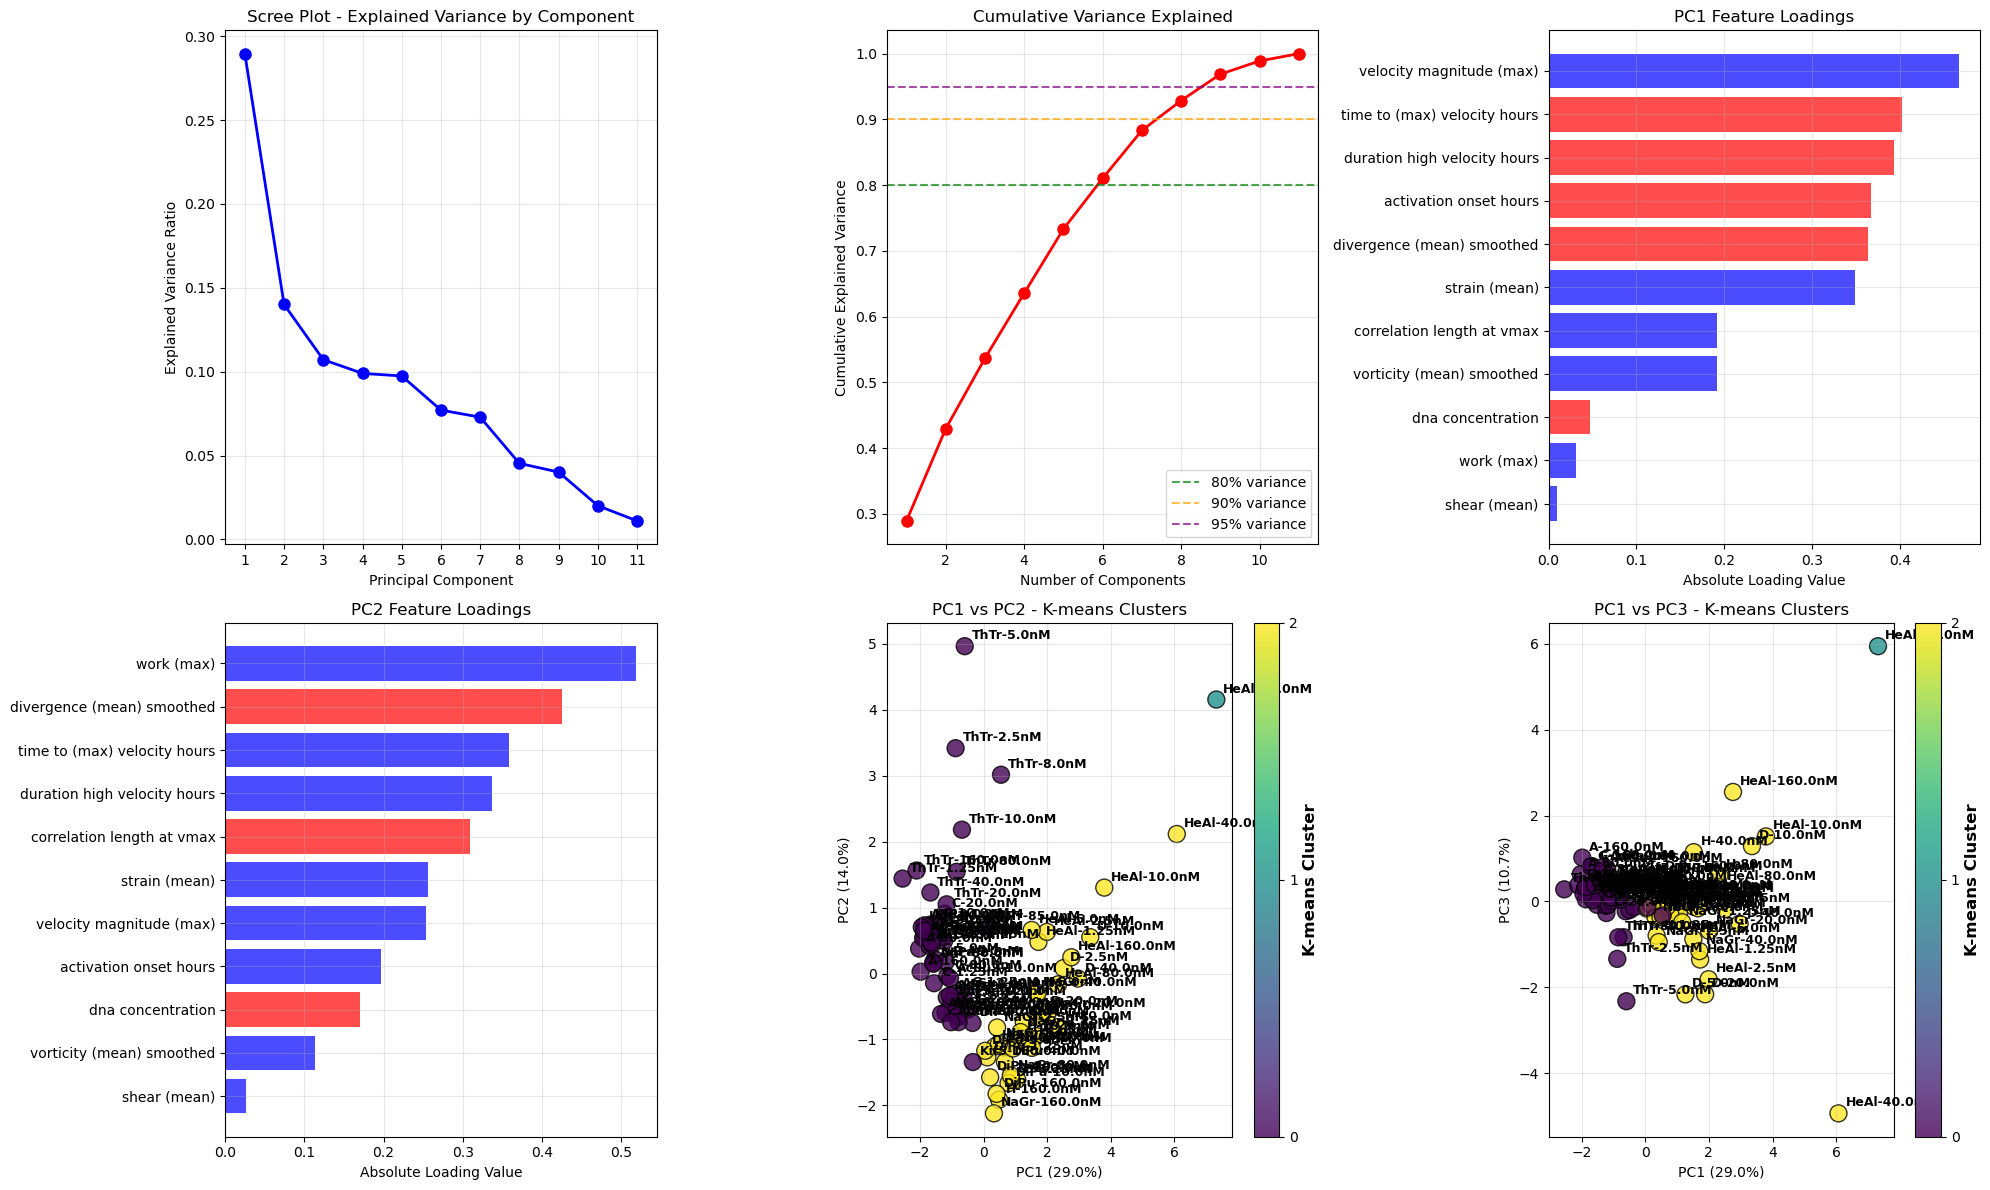


DETAILED VARIANCE EXPLANATION:
Total features used: 11
Total variance explained: 1.0000 (100.00%)
Components for 80% variance: 6
Components for 90% variance: 8
Components for 95% variance: 9

FEATURES USED IN PCA:
 1. velocity_magnitude_max
 2. vorticity_mean_smoothed
 3. shear_mean
 4. strain_mean
 5. divergence_mean_smoothed
 6. correlation_length_at_vmax
 7. work_max
 8. time_to_max_velocity_hours
 9. activation_onset_hours
10. duration_high_velocity_hours
11. dna_concentration

PC1 CONTRIBUTIONS (explains 29.0% of variance):
  velocity_magnitude_max                  : 0.4676 (positive)
  time_to_max_velocity_hours              : 0.4028 (negative)
  duration_high_velocity_hours            : 0.3928 (negative)
  activation_onset_hours                  : 0.3672 (negative)
  divergence_mean_smoothed                : 0.3631 (negative)
  strain_mean                             : 0.3484 (positive)
  correlation_length_at_vmax              : 0.1918 (positive)
  vorticity_mean_smoothed     

In [12]:
# Analyze which features contribute most to each principal component
print("Feature contributions to principal components:")
print("=" * 60)

# Get feature loadings (coefficients)
feature_loadings = pca.components_

# Create a DataFrame for easier analysis
loadings_df = pd.DataFrame(feature_loadings.T, 
                          columns=[f'PC{i+1}' for i in range(len(feature_loadings))],
                          index=feature_columns)

# Helper: create simplified feature labels for plotting
def simplify_label(label):
    # Remove units and underscores, keep only main variable name
    # e.g. "velocity_magnitude_max" -> "velocity max"
    # e.g. "velocity_magnitude_max_median" -> "velocity max (med)"
    # e.g. "work [J]_mean" -> "work (mean)"
    # e.g. "distance [m]_mean" -> "distance (mean)"
    # e.g. "kcat_app_s^-1" -> "kcat"
    import re
    # Remove units in brackets
    label = re.sub(r"\s*\[.*?\]", "", label)
    # Replace underscores with spaces
    label = label.replace("_", " ")
    # Shorten common suffixes
    label = label.replace(" median", " (med)")
    label = label.replace(" mean", " (mean)")
    label = label.replace(" max", " (max)")
    label = label.replace(" min", " (min)")
    label = label.replace(" std", " (std)")
    label = label.replace(" sum", " (sum)")
    label = label.replace(" app", "")
    label = label.replace(" s^-1", "")
    label = label.replace(" per uM", "/uM")
    label = label.replace(" uM", "uM")
    label = label.replace("^-1", "")
    label = label.replace("^-2", "")
    label = label.strip()
    return label

simple_labels = [simplify_label(f) for f in feature_columns]
label_map = dict(zip(feature_columns, simple_labels))

print("\nTop contributing features to PC1:")
pc1_contrib = loadings_df['PC1'].abs().sort_values(ascending=False)
for feature, loading in pc1_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC2:")
pc2_contrib = loadings_df['PC2'].abs().sort_values(ascending=False)
for feature, loading in pc2_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC3:")
pc3_contrib = loadings_df['PC3'].abs().sort_values(ascending=False)
for feature, loading in pc3_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

# Show the full loadings matrix
print("\nFull loadings matrix (first 5 components):")
print(loadings_df.iloc[:, :5].round(4))

# Create a comprehensive visualization of PCA results
print("\n" + "="*80)
print("PCA FEATURE ANALYSIS AND VARIANCE EXPLANATION")
print("="*80)

# Create a comprehensive PCA visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Scree plot
axes[0, 0].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# 2. Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].axhline(y=0.95, color='purple', linestyle='--', alpha=0.7, label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature loadings for PC1
pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC1'].loc[pc1_loadings.index]]
axes[0, 2].barh(range(len(pc1_loadings)), pc1_loadings.values, color=colors, alpha=0.7)
axes[0, 2].set_yticks(range(len(pc1_loadings)))
axes[0, 2].set_yticklabels([label_map[f] for f in pc1_loadings.index], fontsize=10)
axes[0, 2].set_xlabel('Absolute Loading Value')
axes[0, 2].set_title('PC1 Feature Loadings')
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature loadings for PC2
pc2_loadings = loadings_df['PC2'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC2'].loc[pc2_loadings.index]]
axes[1, 0].barh(range(len(pc2_loadings)), pc2_loadings.values, color=colors, alpha=0.7)
axes[1, 0].set_yticks(range(len(pc2_loadings)))
axes[1, 0].set_yticklabels([label_map[f] for f in pc2_loadings.index], fontsize=10)
axes[1, 0].set_xlabel('Absolute Loading Value')
axes[1, 0].set_title('PC2 Feature Loadings')
axes[1, 0].grid(True, alpha=0.3)

# 5. PC1 vs PC2 scatter plot with K-means clusters
scatter = axes[1, 1].scatter(pca_df['PC1'], pca_df['PC2'], 
                            c=feature_df['kmeans_cluster'], 
                            cmap='viridis', s=150, alpha=0.8, edgecolors='black', linewidth=1)
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC2 - K-means Clusters')
axes[1, 1].grid(True, alpha=0.3)

# Add colorbar for K-means clusters
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('K-means Cluster', fontsize=12, fontweight='bold')
cbar.set_ticks(sorted(feature_df['kmeans_cluster'].unique()))

# Add condition labels
for i, condition in enumerate(pca_df.index):
    axes[1, 1].annotate(condition, (pca_df.iloc[i]['PC1'], pca_df.iloc[i]['PC2']), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# 6. PC1 vs PC3 scatter plot
if len(pca_df.columns) > 2:
    scatter = axes[1, 2].scatter(pca_df['PC1'], pca_df['PC3'], 
                                c=feature_df['kmeans_cluster'], 
                                cmap='viridis', s=150, alpha=0.8, edgecolors='black', linewidth=1)
    axes[1, 2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1, 2].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
    axes[1, 2].set_title('PC1 vs PC3 - K-means Clusters')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add colorbar for K-means clusters
    cbar = plt.colorbar(scatter, ax=axes[1, 2])
    cbar.set_label('K-means Cluster', fontsize=12, fontweight='bold')
    cbar.set_ticks(sorted(feature_df['kmeans_cluster'].unique()))
    
    # Add condition labels
    for i, condition in enumerate(pca_df.index):
        axes[1, 2].annotate(condition, (pca_df.iloc[i]['PC1'], pca_df.iloc[i]['PC3']), 
                           xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed variance explanation
print(f"\nDETAILED VARIANCE EXPLANATION:")
print("=" * 50)
print(f"Total features used: {len(feature_columns)}")
print(f"Total variance explained: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1]*100:.2f}%)")
print(f"Components for 80% variance: {np.where(cumulative_variance >= 0.8)[0][0] + 1}")
print(f"Components for 90% variance: {np.where(cumulative_variance >= 0.9)[0][0] + 1}")
print(f"Components for 95% variance: {np.where(cumulative_variance >= 0.95)[0][0] + 1}")

print(f"\nFEATURES USED IN PCA:")
print("=" * 30)
for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

print(f"\nPC1 CONTRIBUTIONS (explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc1_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC1'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")

print(f"\nPC2 CONTRIBUTIONS (explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc2_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC2'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")



BEHAVIORAL CLUSTERING AND TIME SERIES ANALYSIS


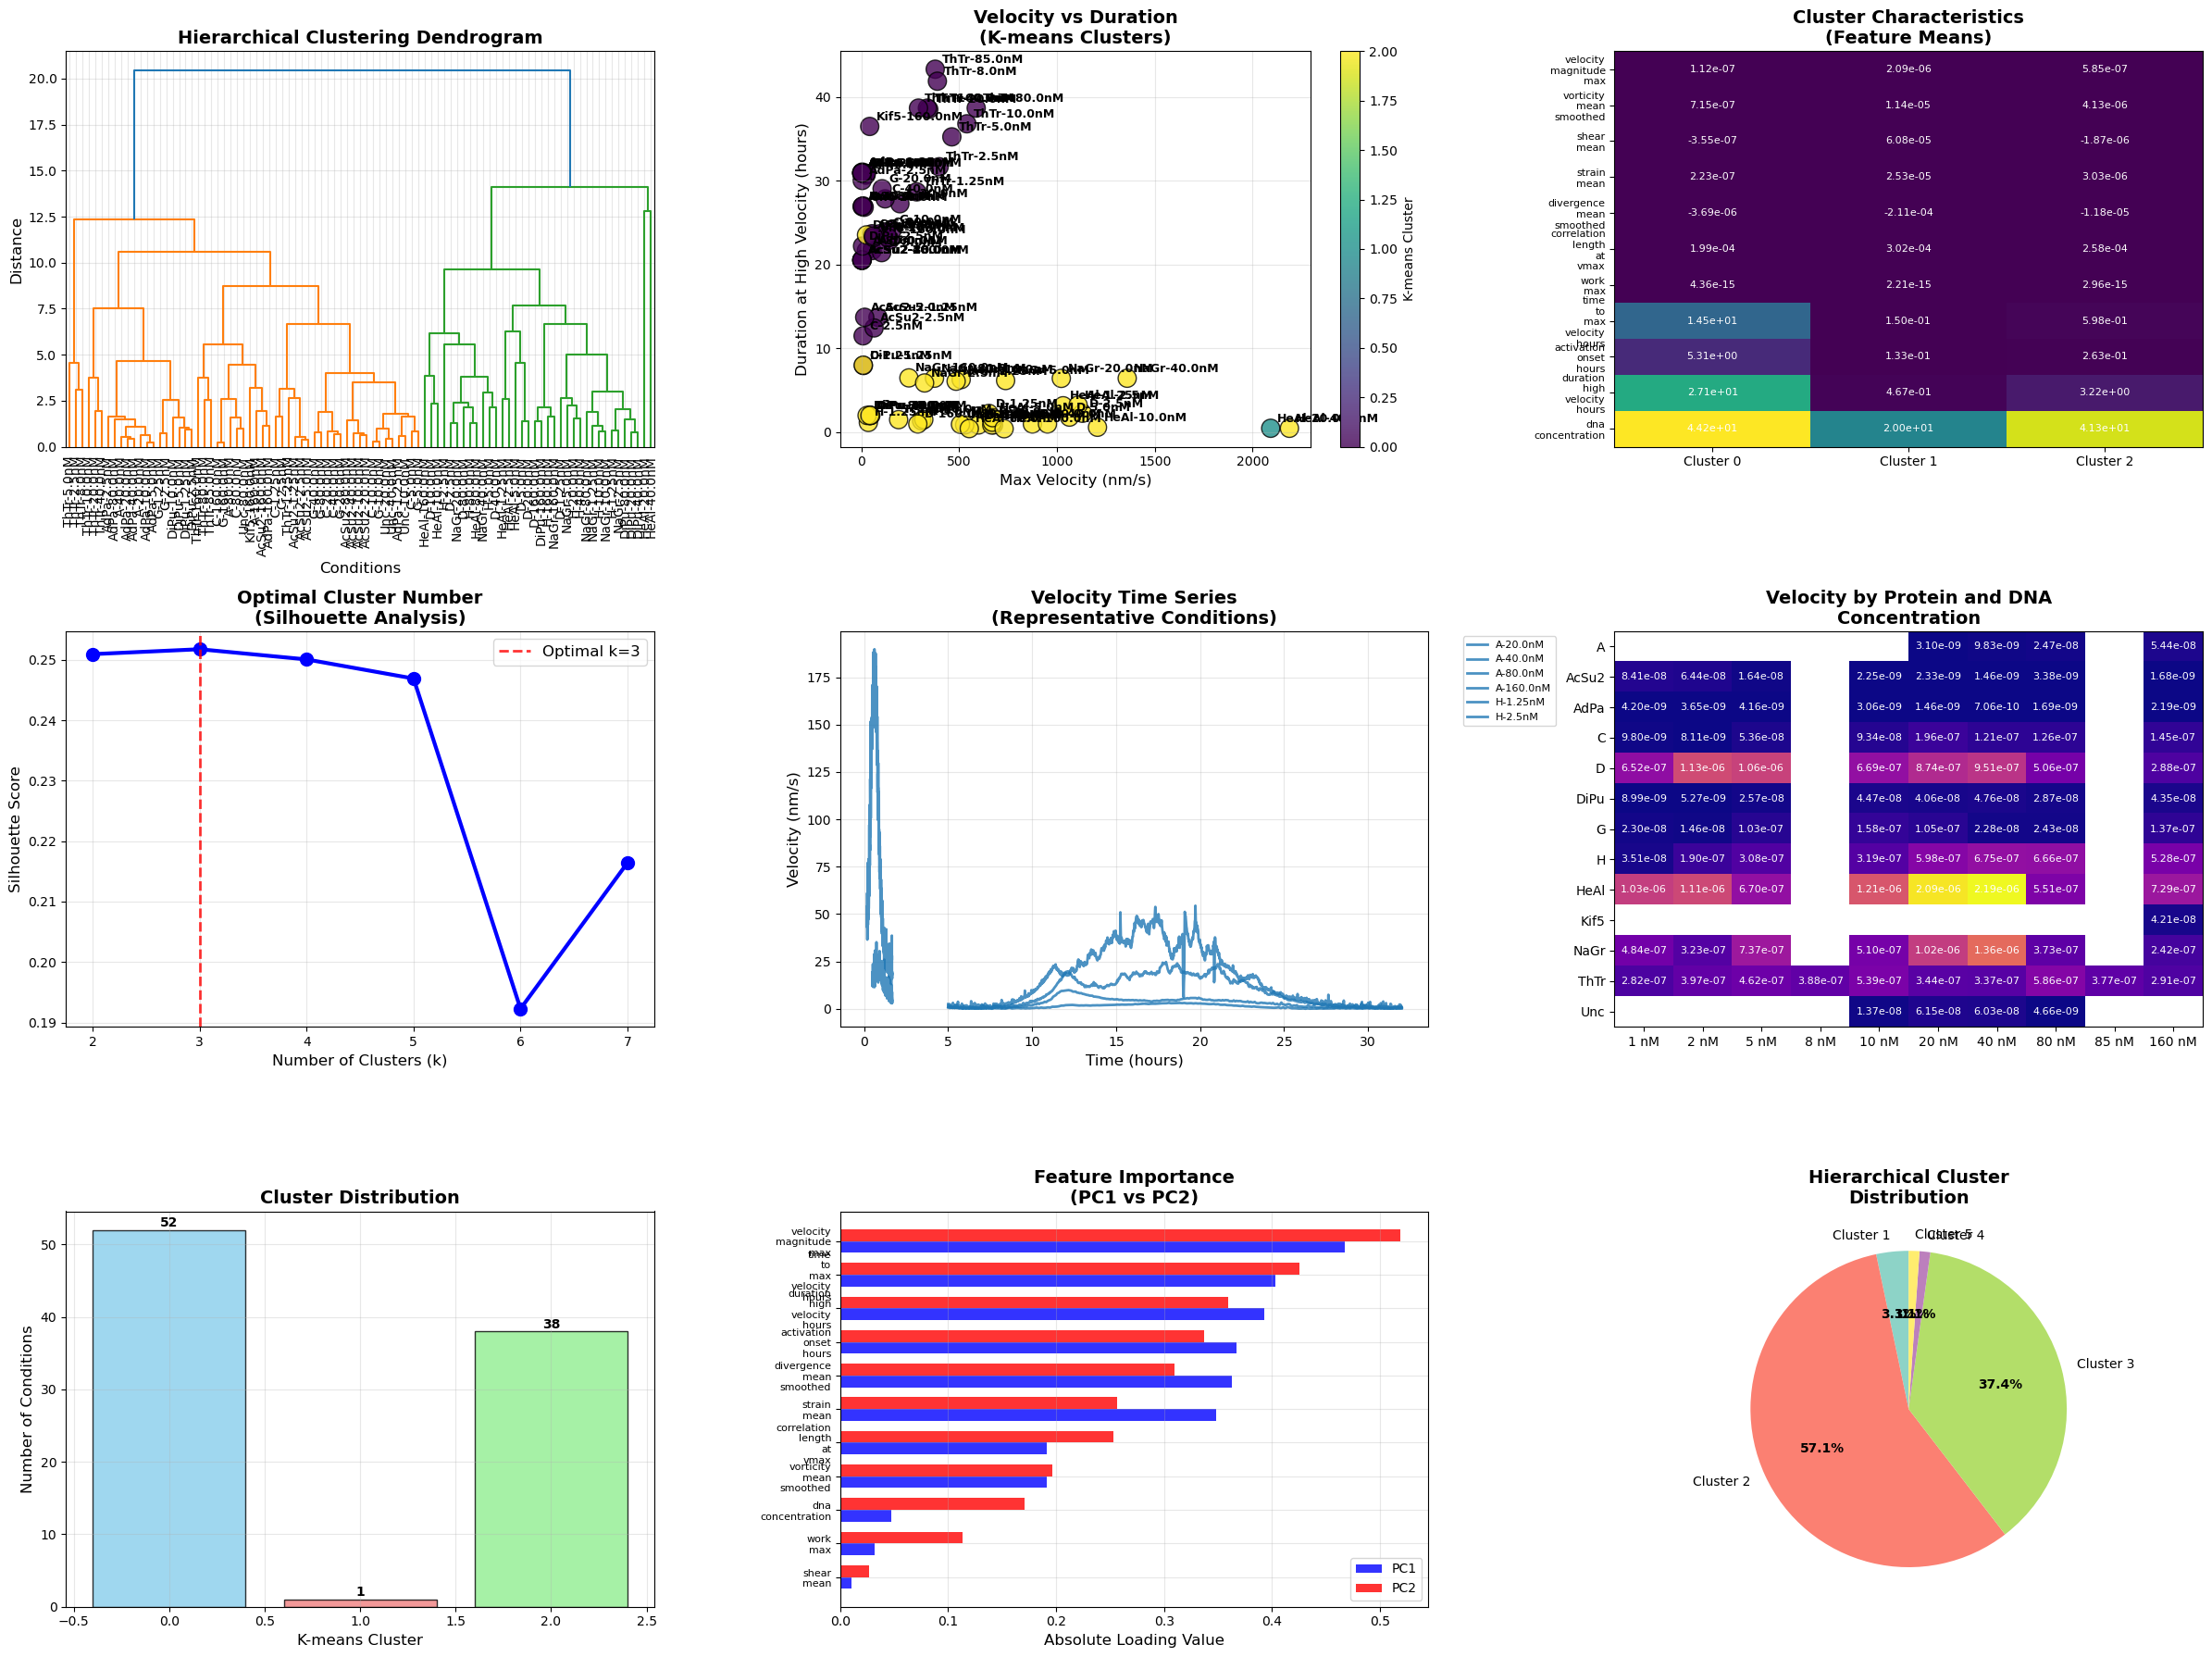


COMPREHENSIVE ANALYSIS SUMMARY
Total conditions analyzed: 91
Features used: 11
PCA components (95% variance): 9
Optimal K-means clusters: 3
Hierarchical clusters: 5
Silhouette score (K-means): 0.252

K-MEANS CLUSTER ASSIGNMENTS:
  Cluster 0: ['A-20.0nM', 'A-40.0nM', 'A-80.0nM', 'A-160.0nM', 'C-1.25nM', 'C-2.5nM', 'C-5.0nM', 'C-10.0nM', 'C-20.0nM', 'C-40.0nM', 'C-80.0nM', 'C-160.0nM', 'G-1.25nM', 'G-2.5nM', 'G-5.0nM', 'G-10.0nM', 'G-20.0nM', 'G-40.0nM', 'G-80.0nM', 'G-160.0nM', 'ThTr-1.25nM', 'ThTr-2.5nM', 'ThTr-5.0nM', 'ThTr-10.0nM', 'ThTr-20.0nM', 'ThTr-40.0nM', 'ThTr-80.0nM', 'ThTr-160.0nM', 'AcSu2-1.25nM', 'AcSu2-2.5nM', 'AcSu2-5.0nM', 'AcSu2-10.0nM', 'AcSu2-20.0nM', 'AcSu2-40.0nM', 'AcSu2-80.0nM', 'AcSu2-160.0nM', 'DiPu-2.5nM', 'AdPa-10.0nM', 'AdPa-160.0nM', 'AdPa-1.25nM', 'AdPa-20.0nM', 'AdPa-2.5nM', 'AdPa-40.0nM', 'AdPa-5.0nM', 'AdPa-80.0nM', 'ThTr-85.0nM', 'ThTr-8.0nM', 'Unc-10.0nM', 'Unc-20.0nM', 'Unc-40.0nM', 'Unc-80.0nM', 'Kif5-160.0nM']
  Cluster 1: ['HeAl-20.0nM']
  Cluste

In [13]:
# Advanced Behavioral Analysis and Clustering Visualizations
print("\n" + "="*80)
print("BEHAVIORAL CLUSTERING AND TIME SERIES ANALYSIS")
print("="*80)

# Create comprehensive behavioral analysis figure
fig, axes = plt.subplots(3, 3, figsize=(24, 18))

# 1. Hierarchical Clustering Dendrogram
dendrogram(linkage_matrix, labels=pca_df.index, leaf_rotation=90, leaf_font_size=10, ax=axes[0, 0])
axes[0, 0].set_title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Conditions', fontsize=12)
axes[0, 0].set_ylabel('Distance', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. Velocity vs Duration with K-means Clusters
velocity_nm_s = feature_df['velocity_magnitude_max'] * 1e9  # Convert to nm/s
duration_hours = feature_df['duration_high_velocity_hours']

# Use K-means cluster colors
scatter = axes[0, 1].scatter(velocity_nm_s, duration_hours, 
                            c=feature_df['kmeans_cluster'], 
                            cmap='viridis', s=200, alpha=0.8, edgecolors='black', linewidth=1)
axes[0, 1].set_xlabel('Max Velocity (nm/s)', fontsize=12)
axes[0, 1].set_ylabel('Duration at High Velocity (hours)', fontsize=12)
axes[0, 1].set_title('Velocity vs Duration\n(K-means Clusters)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Add condition labels
for i, condition in enumerate(feature_df['condition_id']):
    axes[0, 1].annotate(condition, (velocity_nm_s.iloc[i], duration_hours.iloc[i]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Add colorbar for clusters
cbar = plt.colorbar(scatter, ax=axes[0, 1])
cbar.set_label('K-means Cluster', fontsize=10)

# 3. Cluster Characteristics Heatmap
cluster_characteristics = feature_df.groupby('kmeans_cluster')[feature_columns].mean()
im = axes[0, 2].imshow(cluster_characteristics.T.values, cmap='viridis', aspect='auto')
axes[0, 2].set_xticks(range(len(cluster_characteristics.index)))
axes[0, 2].set_xticklabels([f'Cluster {i}' for i in cluster_characteristics.index])
axes[0, 2].set_yticks(range(len(feature_columns)))
axes[0, 2].set_yticklabels([f.replace('_', '\n') for f in feature_columns], fontsize=8)
axes[0, 2].set_title('Cluster Characteristics\n(Feature Means)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(feature_columns)):
    for j in range(len(cluster_characteristics.index)):
        text = axes[0, 2].text(j, i, f'{cluster_characteristics.iloc[j, i]:.2e}', 
                              ha="center", va="center", color="white", fontsize=8)

# 4. Silhouette Score Analysis
axes[1, 0].plot(k_range, silhouette_scores, 'bo-', linewidth=3, markersize=10)
axes[1, 0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.8, linewidth=2, label=f'Optimal k={optimal_k}')
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[1, 0].set_title('Optimal Cluster Number\n(Silhouette Analysis)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 5. Time Series Analysis - Representative Conditions
axes[1, 1].set_title('Velocity Time Series\n(Representative Conditions)', fontsize=14, fontweight='bold')
colors_ts = plt.cm.tab10(np.linspace(0, 1, len(feature_df['condition_id'].unique())))
for i, condition in enumerate(feature_df['condition_id'].unique()[:6]):  # Show first 6 conditions
    try:
        condition_data = df[df['protein'] == condition].sort_values('time (s)')
        if len(condition_data) > 0:
            velocity_nm_s = condition_data['velocity magnitude [m/s]_mean'] * 1e9
            time_hours = condition_data['time (s)'] / 3600
            # Only plot if we have valid data
            valid_data = ~(velocity_nm_s.isna() | time_hours.isna())
            if valid_data.any():
                axes[1, 1].plot(time_hours[valid_data], velocity_nm_s[valid_data], 
                               label=condition, color=colors_ts[i], linewidth=2, alpha=0.8)
    except Exception as e:
        print(f"Error plotting time series for {condition}: {e}")
        continue

axes[1, 1].set_xlabel('Time (hours)', fontsize=12)
axes[1, 1].set_ylabel('Velocity (nm/s)', fontsize=12)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# 6. Protein vs DNA Concentration Heatmap
protein_dna_pivot = feature_df.pivot_table(
    values='velocity_magnitude_max', 
    index='protein_name', 
    columns='dna_concentration', 
    aggfunc='mean'
)
im = axes[1, 2].imshow(protein_dna_pivot.values, cmap='plasma', aspect='auto')
axes[1, 2].set_xticks(range(len(protein_dna_pivot.columns)))
axes[1, 2].set_xticklabels([f'{int(x)} nM' for x in protein_dna_pivot.columns])
axes[1, 2].set_yticks(range(len(protein_dna_pivot.index)))
axes[1, 2].set_yticklabels(protein_dna_pivot.index)
axes[1, 2].set_title('Velocity by Protein and DNA\nConcentration', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(protein_dna_pivot.index)):
    for j in range(len(protein_dna_pivot.columns)):
        text = axes[1, 2].text(j, i, f'{protein_dna_pivot.iloc[i, j]:.2e}', 
                              ha="center", va="center", color="white", fontsize=8)

# 7. Cluster Distribution
cluster_counts = feature_df['kmeans_cluster'].value_counts().sort_index()
bars = axes[2, 0].bar(cluster_counts.index, cluster_counts.values, 
                     color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum'][:len(cluster_counts)], 
                     alpha=0.8, edgecolor='black', linewidth=1)
axes[2, 0].set_xlabel('K-means Cluster', fontsize=12)
axes[2, 0].set_ylabel('Number of Conditions', fontsize=12)
axes[2, 0].set_title('Cluster Distribution', fontsize=14, fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts.values):
    axes[2, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                   str(count), ha='center', va='bottom', fontweight='bold')

# 8. Feature Importance Comparison
pc1_weights = np.abs(loadings_df['PC1']).sort_values(ascending=True)
pc2_weights = np.abs(loadings_df['PC2']).sort_values(ascending=True)

x_pos = np.arange(len(pc1_weights))
width = 0.35

axes[2, 1].barh(x_pos - width/2, pc1_weights.values, width, label='PC1', alpha=0.8, color='blue')
axes[2, 1].barh(x_pos + width/2, pc2_weights.values, width, label='PC2', alpha=0.8, color='red')
axes[2, 1].set_yticks(x_pos)
axes[2, 1].set_yticklabels([f.replace('_', '\n') for f in pc1_weights.index], fontsize=8)
axes[2, 1].set_xlabel('Absolute Loading Value', fontsize=12)
axes[2, 1].set_title('Feature Importance\n(PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# 9. Hierarchical Cluster Distribution
hierarchical_counts = feature_df['hierarchical_cluster'].value_counts().sort_index()
colors_hierarchical = plt.cm.Set3(np.linspace(0, 1, len(hierarchical_counts)))
wedges, texts, autotexts = axes[2, 2].pie(hierarchical_counts.values, 
                                         labels=[f'Cluster {i}' for i in hierarchical_counts.index], 
                                         colors=colors_hierarchical, autopct='%1.1f%%', startangle=90)
axes[2, 2].set_title('Hierarchical Cluster\nDistribution', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

# Print comprehensive final summary
print(f"\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)
print(f"Total conditions analyzed: {len(feature_df)}")
print(f"Features used: {len(feature_columns)}")
print(f"PCA components (95% variance): {n_components_95}")
print(f"Optimal K-means clusters: {optimal_k}")
print(f"Hierarchical clusters: {len(feature_df['hierarchical_cluster'].unique())}")
print(f"Silhouette score (K-means): {max(silhouette_scores):.3f}")

print(f"\nK-MEANS CLUSTER ASSIGNMENTS:")
print("=" * 40)
for cluster in sorted(feature_df['kmeans_cluster'].unique()):
    cluster_conditions = feature_df[feature_df['kmeans_cluster'] == cluster]['condition_id'].tolist()
    print(f"  Cluster {cluster}: {cluster_conditions}")

print(f"\nHIERARCHICAL CLUSTER ASSIGNMENTS:")
print("=" * 40)
for cluster in sorted(feature_df['hierarchical_cluster'].unique()):
    cluster_conditions = feature_df[feature_df['hierarchical_cluster'] == cluster]['condition_id'].tolist()
    print(f"  Hierarchical Cluster {cluster}: {cluster_conditions}")

print(f"\nCLUSTER COMPARISON:")
print("=" * 40)
comparison_df = feature_df[['condition_id', 'protein_name', 'dna_concentration', 
                          'kmeans_cluster', 'hierarchical_cluster']].copy()
print(comparison_df.to_string(index=False))


In [14]:
# Error handling and data validation
print("=== Data Validation and Error Check ===")

# Check if all required variables exist
required_vars = ['df', 'feature_df', 'pca_df', 'X_scaled_df']
missing_vars = [var for var in required_vars if var not in locals()]
if missing_vars:
    print(f"Warning: Missing variables: {missing_vars}")

# Check data shapes
print(f"Original data shape: {df.shape if 'df' in locals() else 'Not found'}")
print(f"Feature data shape: {feature_df.shape if 'feature_df' in locals() else 'Not found'}")
print(f"PCA data shape: {pca_df.shape if 'pca_df' in locals() else 'Not found'}")

# Check for any NaN values in key variables
if 'feature_df' in locals():
    nan_counts = feature_df.isnull().sum()
    if nan_counts.sum() > 0:
        print(f"NaN values in feature_df: {nan_counts[nan_counts > 0].to_dict()}")
    else:
        print("No NaN values in feature_df")

# Check clustering results
if 'feature_df' in locals() and 'kmeans_cluster' in feature_df.columns:
    print(f"K-means clusters: {feature_df['kmeans_cluster'].value_counts().to_dict()}")
if 'feature_df' in locals() and 'hierarchical_cluster' in feature_df.columns:
    print(f"Hierarchical clusters: {feature_df['hierarchical_cluster'].value_counts().to_dict()}")

print("=== Analysis Complete ===")


=== Data Validation and Error Check ===
Original data shape: (177776, 13)
Feature data shape: (91, 19)
PCA data shape: (91, 9)
No NaN values in feature_df
K-means clusters: {0: 52, 2: 38, 1: 1}
Hierarchical clusters: {2: 52, 3: 34, 1: 3, 4: 1, 5: 1}
=== Analysis Complete ===


OK now let's try to somehow get a classification of proteins only, not divided
by dna nM but factoring that include

## Protein-level classification (DNA factored in)
Goal: classify proteins (not conditions) by aggregating dynamics across DNA concentrations and incorporating kinetic summaries.

Strategy:
- Aggregate `feature_df` over `protein_name` using robust summaries (median/maximum) for intensity, persistence, and organization features.
- Incorporate kinetic parameters from the saturation fits (`Km`, `kcat_app`, `kcat/Km`) when available.
- Standardize, run PCA (retain ≥95% variance), inspect loadings.
- Find natural clusters via K-means (silhouette-optimized k) and hierarchical clustering (silhouette-optimized maxclust), then visualize with PCA plots and a dendrogram.

This yields clusters of proteins that summarize behavior across DNA levels rather than per-condition.


In [15]:
# Build protein-level feature table aggregating across DNA

# Base features to summarize from condition-level table
base_feats = {
    'velocity_magnitude_max': ['max'],
    'duration_high_velocity_hours': ['median','max'],
    'time_to_max_velocity_hours': ['median'],
    'activation_onset_hours': ['median'],
    'vorticity_mean_smoothed': ['median'],
    'divergence_mean_smoothed': ['median'],
    'correlation_length_at_vmax': ['median'],
    'work_max': ['median','max'],
    'shear_mean': ['median'],
    'strain_mean': ['median']
}

agg = feature_df.groupby('protein_name').agg({k: v for k, v in base_feats.items()})
# Flatten multiindex columns
agg.columns = [f"{feat}_{stat}" for feat, stat in agg.columns]

# Per request: do not include kinetic summaries (Km, kcat, kcat/Km)
protein_df = agg.copy()

print('Protein-level feature matrix shape:', protein_df.shape)
protein_df


Protein-level feature matrix shape: (13, 12)


,velocity_magnitude_max_max,duration_high_velocity_hours_median,duration_high_velocity_hours_max,time_to_max_velocity_hours_median,activation_onset_hours_median,vorticity_mean_smoothed_median,divergence_mean_smoothed_median,correlation_length_at_vmax_median,work_max_median,work_max_max,shear_mean_median,strain_mean_median
protein_name,,,,,,,,,,,,
A,5.441118e-08,24.308333,27.000000,18.050000,7.691667,2.045888e-07,8.481151e-07,0.000304,7.701927e-18,5.711638e-17,2.614271e-07,1.322262e-07
AcSu2,8.407517e-08,20.513889,20.555556,10.638889,5.041667,1.633760e-09,8.193367e-08,0.000167,3.696389e-18,1.136368e-16,-1.367847e-09,1.827882e-08
AdPa,4.199285e-09,30.950000,31.050000,11.325000,5.100000,3.027809e-09,1.514737e-07,0.000375,6.734686e-20,1.959047e-19,-6.622258e-09,4.796022e-09
C,1.964161e-07,23.687500,27.854167,13.770833,7.208333,-2.685270e-07,-2.670663e-06,0.000057,8.718403e-16,6.129248e-15,3.388977e-07,-2.128987e-07
D,1.129651e-06,1.086667,2.257778,0.216667,0.101111,3.310370e-06,-1.137146e-05,0.000259,1.918326e-15,5.621630e-15,1.694322e-06,6.428146e-06
DiPu,4.763397e-08,2.000000,23.555556,0.888889,0.000000,-2.364967e-07,9.497742e-07,0.000260,2.650935e-19,2.702945e-18,4.904415e-08,5.205788e-08
G,1.576391e-07,29.875000,30.895833,13.770833,1.020833,-6.706052e-08,-4.035972e-07,0.000117,5.102826e-17,2.675333e-15,4.714975e-08,4.010390e-08
H,6.750709e-07,1.022222,1.511111,0.264444,0.148889,1.685913e-06,-1.359345e-05,0.000251,5.287152e-16,9.126720e-16,3.432761e-06,1.831967e-06
HeAl,2.187885e-06,0.527500,3.236667,0.247500,0.215833,7.848188e-06,-4.827728e-05,0.000273,4.581218e-15,2.793263e-14,-8.422390e-07,1.194003e-05


In [16]:
# PCA and clustering at protein level

# Prepare matrix
y = protein_df.copy()
# Convert any remaining NaNs to column medians
for col in y.columns:
    if y[col].isna().any():
        y[col] = y[col].fillna(y[col].median())

scaler_p = StandardScaler()
Y_scaled = scaler_p.fit_transform(y)
Y_scaled_df = pd.DataFrame(Y_scaled, columns=y.columns, index=protein_df.index)

# PCA
pca_p = PCA()
Y_pca = pca_p.fit_transform(Y_scaled)
cumvar_p = np.cumsum(pca_p.explained_variance_ratio_)
ncomp95_p = np.argmax(cumvar_p >= 0.95) + 1

prot_pca_df = pd.DataFrame(Y_pca[:, :ncomp95_p], columns=[f'PC{i+1}' for i in range(ncomp95_p)], index=protein_df.index)
prot_loadings = pd.DataFrame(pca_p.components_[:ncomp95_p].T, columns=[f'PC{i+1}' for i in range(ncomp95_p)], index=y.columns)

print('Protein PCA: components to 95% variance =', ncomp95_p)
print('Top loadings PC1:')
print(prot_loadings['PC1'].abs().sort_values(ascending=False).head(8))

# K-means with silhouette-optimized k
from sklearn.metrics import silhouette_score
best_k_p, best_s_p, best_labels_p = None, -1, None
for k in range(2, min(8, len(protein_df))):
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(prot_pca_df)
    s = silhouette_score(prot_pca_df, lab)
    if s > best_s_p:
        best_k_p, best_s_p, best_labels_p = k, s, lab

protein_kmeans_labels = best_labels_p

# Hierarchical with natural-k selection
linkage_p = linkage(prot_pca_df, method='ward')
h_sil_p = {}
for k in range(2, min(8, len(protein_df))):
    lab = fcluster(linkage_p, t=k, criterion='maxclust')
    try:
        h_sil_p[k] = silhouette_score(prot_pca_df, lab)
    except Exception:
        h_sil_p[k] = -1
best_hk_p = max(h_sil_p, key=h_sil_p.get)
protein_h_labels = fcluster(linkage_p, t=best_hk_p, criterion='maxclust')

print(f'Protein-level K-means best k={best_k_p} (sil={best_s_p:.3f}); Hierarchical best k={best_hk_p} (sil={h_sil_p[best_hk_p]:.3f})')

# Store
protein_df_out = protein_df.copy()
protein_df_out['kmeans_cluster'] = protein_kmeans_labels
protein_df_out['hierarchical_cluster'] = protein_h_labels
protein_df_out


Protein PCA: components to 95% variance = 6
Top loadings PC1:
velocity_magnitude_max_max             0.404972
vorticity_mean_smoothed_median         0.401173
strain_mean_median                     0.367310
divergence_mean_smoothed_median        0.362201
duration_high_velocity_hours_max       0.341849
duration_high_velocity_hours_median    0.325831
activation_onset_hours_median          0.267038
time_to_max_velocity_hours_median      0.261238
Name: PC1, dtype: float64
Protein-level K-means best k=3 (sil=0.362); Hierarchical best k=3 (sil=0.362)


,velocity_magnitude_max_max,duration_high_velocity_hours_median,duration_high_velocity_hours_max,time_to_max_velocity_hours_median,activation_onset_hours_median,vorticity_mean_smoothed_median,divergence_mean_smoothed_median,correlation_length_at_vmax_median,work_max_median,work_max_max,shear_mean_median,strain_mean_median,kmeans_cluster,hierarchical_cluster
protein_name,,,,,,,,,,,,,,
A,5.441118e-08,24.308333,27.000000,18.050000,7.691667,2.045888e-07,8.481151e-07,0.000304,7.701927e-18,5.711638e-17,2.614271e-07,1.322262e-07,1,2
AcSu2,8.407517e-08,20.513889,20.555556,10.638889,5.041667,1.633760e-09,8.193367e-08,0.000167,3.696389e-18,1.136368e-16,-1.367847e-09,1.827882e-08,1,2
AdPa,4.199285e-09,30.950000,31.050000,11.325000,5.100000,3.027809e-09,1.514737e-07,0.000375,6.734686e-20,1.959047e-19,-6.622258e-09,4.796022e-09,1,2
C,1.964161e-07,23.687500,27.854167,13.770833,7.208333,-2.685270e-07,-2.670663e-06,0.000057,8.718403e-16,6.129248e-15,3.388977e-07,-2.128987e-07,1,2
D,1.129651e-06,1.086667,2.257778,0.216667,0.101111,3.310370e-06,-1.137146e-05,0.000259,1.918326e-15,5.621630e-15,1.694322e-06,6.428146e-06,2,1
DiPu,4.763397e-08,2.000000,23.555556,0.888889,0.000000,-2.364967e-07,9.497742e-07,0.000260,2.650935e-19,2.702945e-18,4.904415e-08,5.205788e-08,1,2
G,1.576391e-07,29.875000,30.895833,13.770833,1.020833,-6.706052e-08,-4.035972e-07,0.000117,5.102826e-17,2.675333e-15,4.714975e-08,4.010390e-08,1,2
H,6.750709e-07,1.022222,1.511111,0.264444,0.148889,1.685913e-06,-1.359345e-05,0.000251,5.287152e-16,9.126720e-16,3.432761e-06,1.831967e-06,2,1
HeAl,2.187885e-06,0.527500,3.236667,0.247500,0.215833,7.848188e-06,-4.827728e-05,0.000273,4.581218e-15,2.793263e-14,-8.422390e-07,1.194003e-05,2,1


## Visual: Top motor per PCA feature (bar panels)
For each aggregated feature used in the protein-level PCA, this figure shows the motor with the highest value and the magnitude of that value (after pooling across DNA).


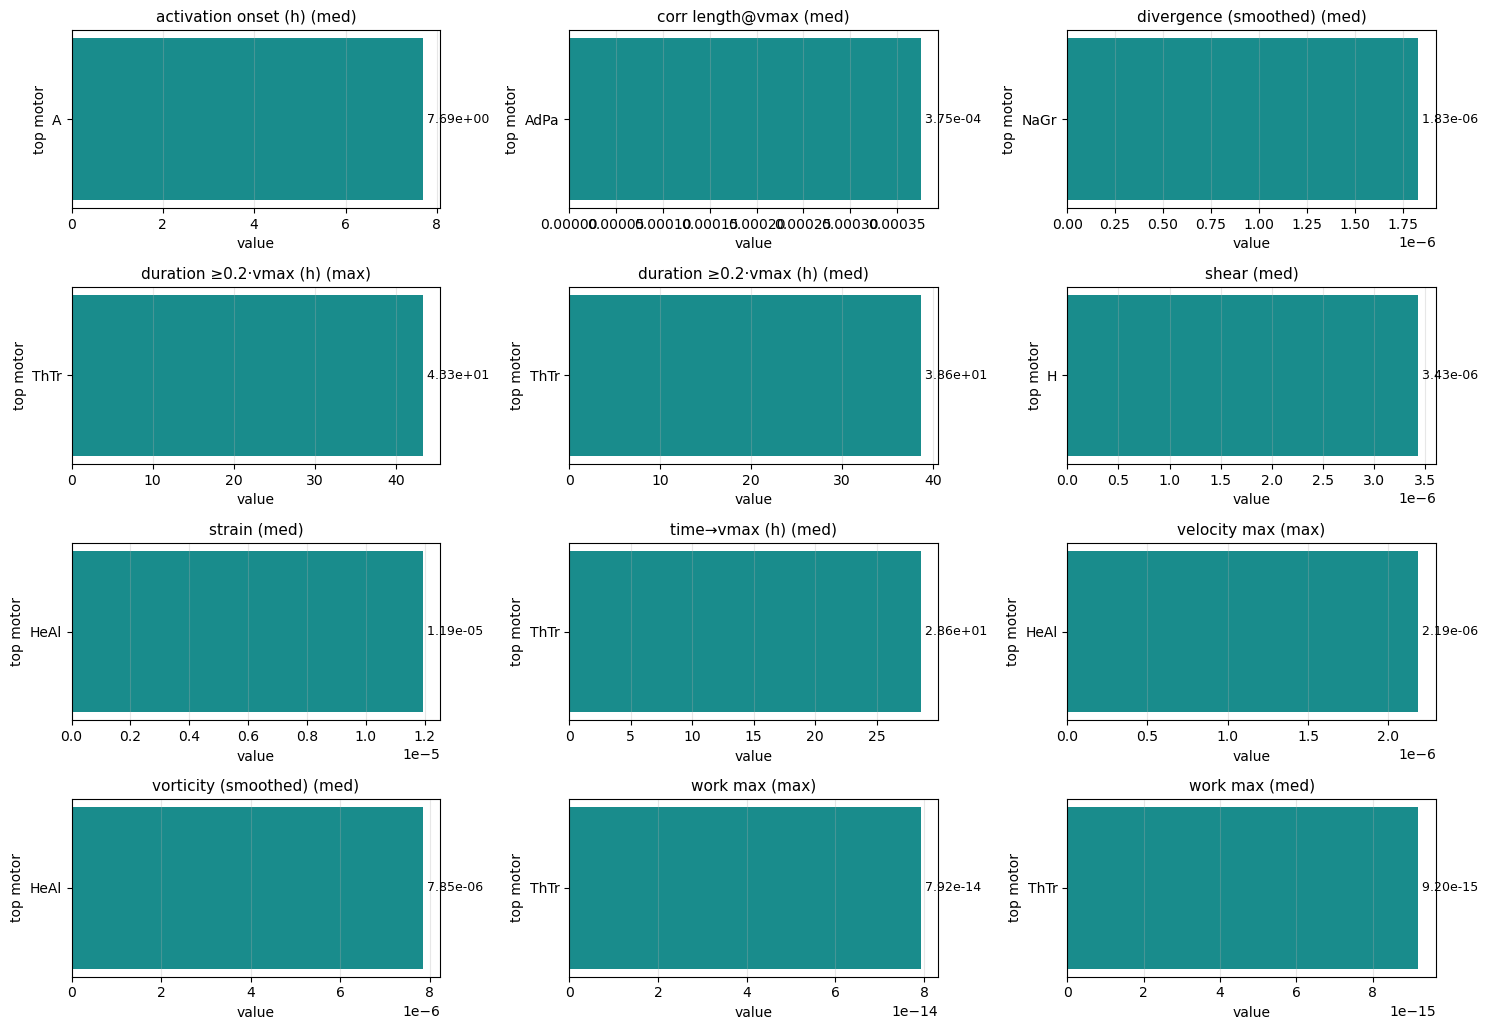

,feature_nice,motor,value
0,activation onset (h) (med),A,7.691667e+00
1,corr length@vmax (med),AdPa,3.751905e-04
2,divergence (smoothed) (med),NaGr,1.832862e-06
3,duration ≥0.2·vmax (h) (max),ThTr,4.333333e+01
4,duration ≥0.2·vmax (h) (med),ThTr,3.861750e+01
5,shear (med),H,3.432761e-06
6,strain (med),HeAl,1.194003e-05
7,time→vmax (h) (med),ThTr,2.856750e+01
8,velocity max (max),HeAl,2.187885e-06
9,vorticity (smoothed) (med),HeAl,7.848188e-06


In [17]:
# Build a visual panel of top motors per feature

# Choose the subset of features actually used in protein_df (numeric)
feat_cols = protein_df.select_dtypes(include=[np.number]).columns.tolist()

# Compute top motor per feature
tops = []
for col in feat_cols:
    try:
        idx = protein_df[col].idxmax()
        val = protein_df.loc[idx, col]
        tops.append({'feature': col, 'motor': idx, 'value': val})
    except Exception:
        continue

tops_df = pd.DataFrame(tops)

# Friendly labels
def nice_label(lbl: str) -> str:
    m = {
        'velocity_magnitude_': 'velocity ',
        'duration_high_velocity_hours': 'duration ≥0.2·vmax (h)',
        'time_to_max_velocity_hours': 'time→vmax (h)',
        'activation_onset_hours': 'activation onset (h)',
        'vorticity_mean_smoothed': 'vorticity (smoothed)',
        'divergence_mean_smoothed': 'divergence (smoothed)',
        'correlation_length_at_vmax': 'corr length@vmax',
        'work_': 'work ',
        'shear_mean': 'shear',
        'strain_mean': 'strain'
    }
    s = lbl
    for k, v in m.items():
        s = s.replace(k, v)
    s = (s.replace('_median', ' (med)')
           .replace('_mean', ' (mean)')
           .replace('_max', ' (max)')
           .replace('_', ' ')  
           .strip())
    return s

tops_df['feature_nice'] = tops_df['feature'].apply(nice_label)

# Plot as multi-panel bars
n = len(tops_df)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 2.6*rows))
axes = np.array(axes).reshape(rows, cols)

for i, (_, row) in enumerate(tops_df.sort_values('feature_nice').iterrows()):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.barh([row['motor']], [row['value']], color='teal', alpha=0.9)
    ax.set_title(row['feature_nice'], fontsize=11)
    ax.set_xlabel('value')
    ax.set_ylabel('top motor')
    # value label
    ax.text(row['value'], 0, f" {row['value']:.2e}", va='center', ha='left', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

# Hide empty axes
for j in range(i+1, rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].set_visible(False)

plt.tight_layout()
plt.show()

tops_df[['feature_nice','motor','value']].sort_values('feature_nice').reset_index(drop=True)


## Protein-level PCA: visual explanation of variance and feature contributions
We visualize which aggregated features contribute most to the protein-level principal components.
- Cumulative variance curve to justify component count.
- Signed loading bar charts for PC1 and PC2 (color encodes sign).
- Loadings heatmap across the first few PCs for a compact overview.


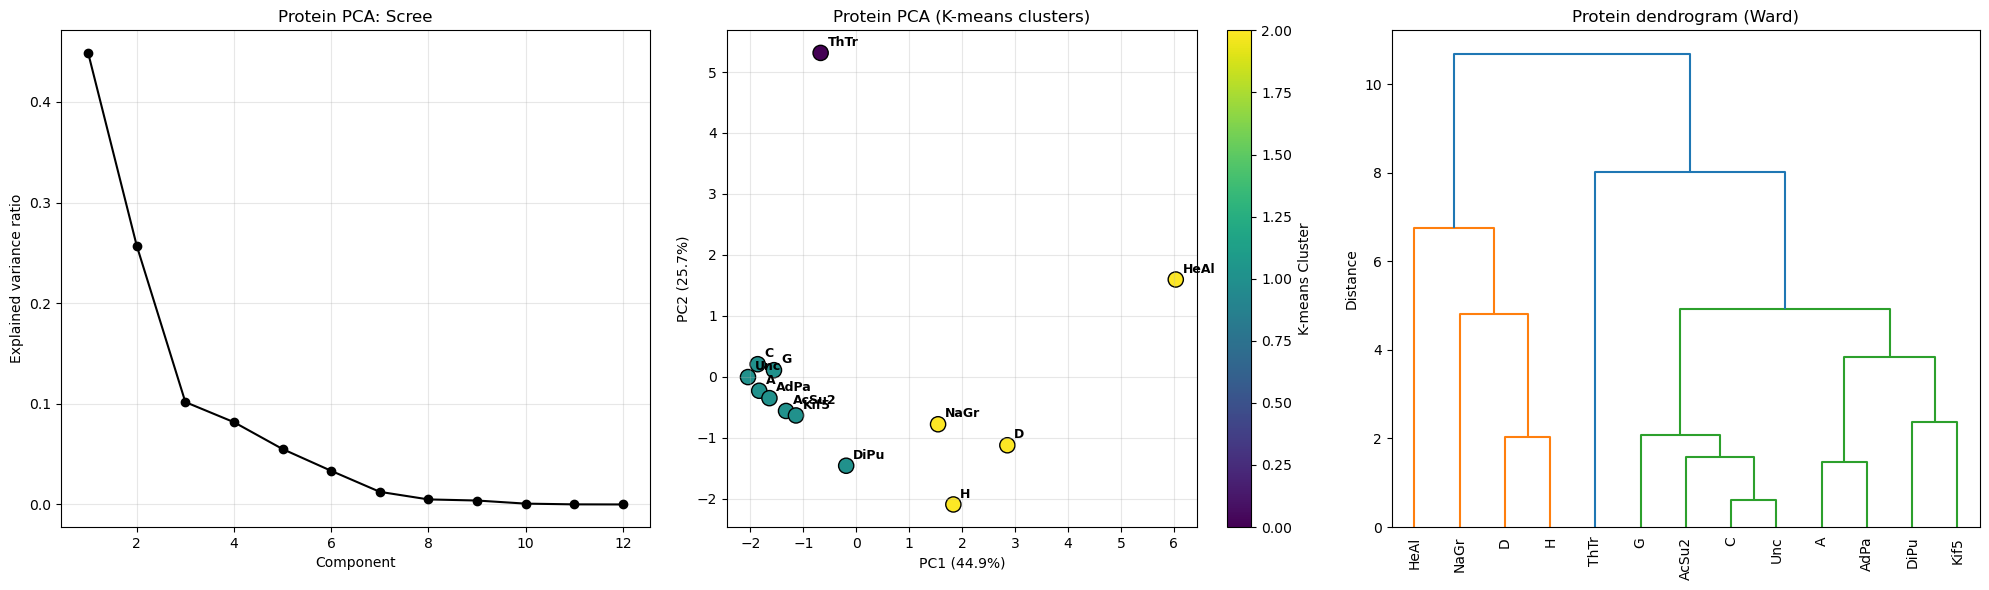


Protein-level loadings (top contributors per PC):

PC1:
  velocity_magnitude_max_max: 0.405
  vorticity_mean_smoothed_median: 0.401
  strain_mean_median: 0.367
  divergence_mean_smoothed_median: 0.362
  duration_high_velocity_hours_max: 0.342
  duration_high_velocity_hours_median: 0.326

PC2:
  work_max_max: 0.533
  work_max_median: 0.509
  time_to_max_velocity_hours_median: 0.395
  duration_high_velocity_hours_max: 0.276
  duration_high_velocity_hours_median: 0.275
  shear_mean_median: 0.250

PC3:
  correlation_length_at_vmax_median: 0.711
  activation_onset_hours_median: 0.438
  shear_mean_median: 0.315
  time_to_max_velocity_hours_median: 0.242
  duration_high_velocity_hours_max: 0.216
  divergence_mean_smoothed_median: 0.180


In [18]:
# Protein-level visualizations: PCA + dendrogram
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Scree
axes[0].plot(range(1, len(pca_p.explained_variance_ratio_)+1), pca_p.explained_variance_ratio_, 'o-', color='black')
axes[0].set_title('Protein PCA: Scree')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].grid(True, alpha=0.3)

# PCA scatter with K-means clusters
sc = axes[1].scatter(prot_pca_df['PC1'], prot_pca_df['PC2'], c=protein_kmeans_labels, cmap='viridis', s=120, edgecolors='black')
for i, name in enumerate(prot_pca_df.index):
    axes[1].annotate(name, (prot_pca_df.iloc[i]['PC1'], prot_pca_df.iloc[i]['PC2']), xytext=(5,5), textcoords='offset points', fontsize=9, fontweight='bold')
axes[1].set_xlabel(f"PC1 ({pca_p.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_p.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title('Protein PCA (K-means clusters)')
plt.colorbar(sc, ax=axes[1], label='K-means Cluster')
axes[1].grid(True, alpha=0.3)

# Dendrogram (hierarchical on proteins)
dendrogram(linkage_p, labels=prot_pca_df.index.tolist(), leaf_rotation=90, leaf_font_size=10, ax=axes[2])
axes[2].set_title('Protein dendrogram (Ward)')
axes[2].set_ylabel('Distance')

plt.tight_layout()
plt.show()

print('\nProtein-level loadings (top contributors per PC):')
for pc in prot_loadings.columns[:min(3, len(prot_loadings.columns))]:
    top = prot_loadings[pc].abs().sort_values(ascending=False).head(6)
    print(f"\n{pc}:")
    for feat, val in top.items():
        print(f"  {feat}: {val:.3f}")


## Protein-level PCA, variance, loadings, scatter, and dendrogram (single figure)
A compact 2×3 panel matching the requested layout:
1) Scree; 2) Cumulative variance; 3) PC1 loadings; 4) PC2 loadings; 5) PC1 vs PC2 with K-means colorbar; 6) Hierarchical dendrogram.


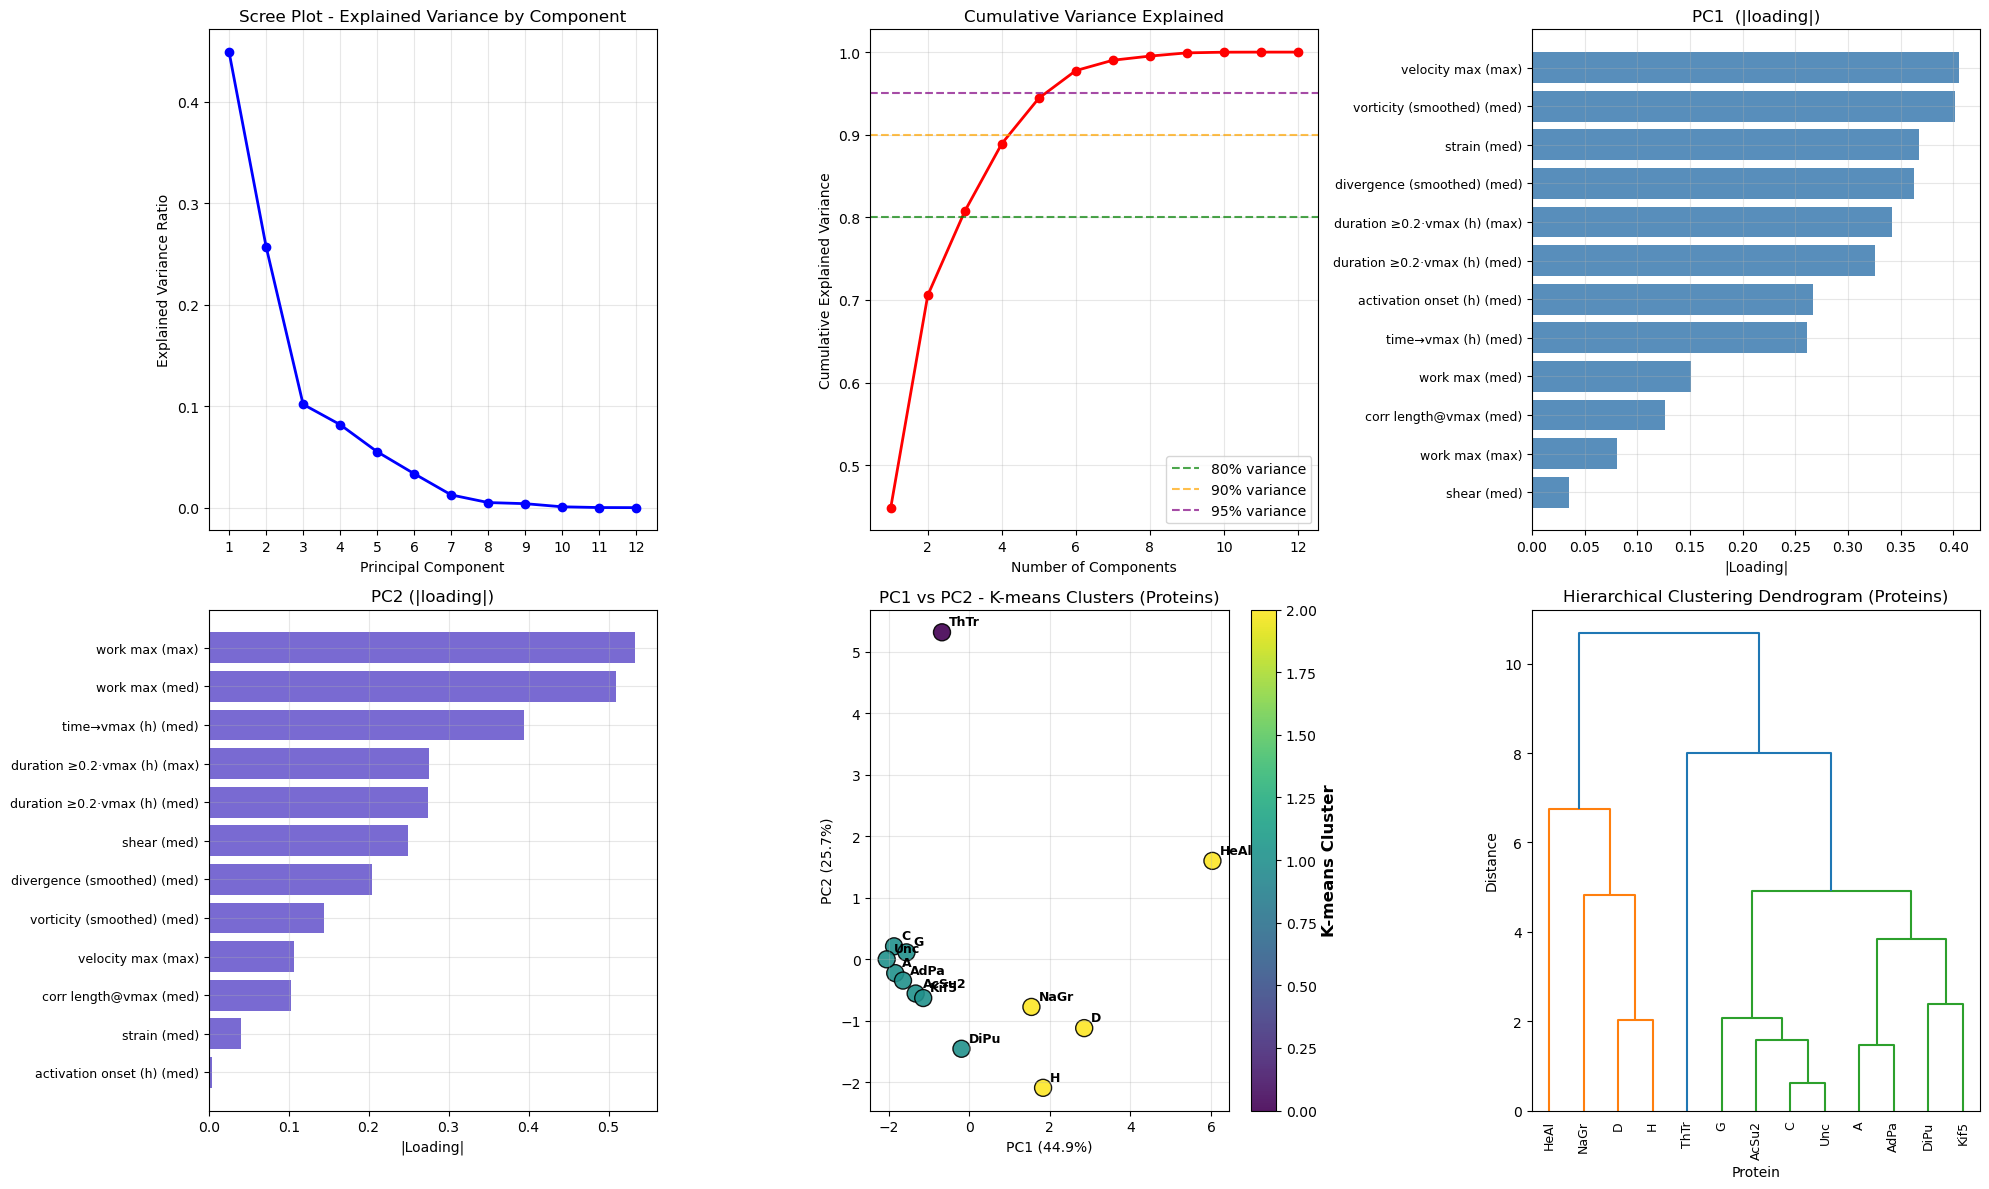

In [19]:
# Single-figure protein PCA summary with dendrogram
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Scree
axes[0, 0].plot(range(1, len(pca_p.explained_variance_ratio_)+1), pca_p.explained_variance_ratio_, 'bo-', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(pca_p.explained_variance_ratio_)+1))

# 2. Cumulative variance
cumvar = np.cumsum(pca_p.explained_variance_ratio_)
axes[0, 1].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', linewidth=2, markersize=6)
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].axhline(y=0.95, color='purple', linestyle='--', alpha=0.7, label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. PC1 importance (|loading|)
pc1_abs = prot_loadings['PC1'].abs().sort_values()
axes[0, 2].barh(range(len(pc1_abs)), pc1_abs.values, color='steelblue', alpha=0.9)
axes[0, 2].set_yticks(range(len(pc1_abs)))
# simplify labels for readability
def simplify_label(lbl: str) -> str:
    m = {
        'velocity_magnitude_': 'velocity ',
        'duration_high_velocity_hours': 'duration ≥0.2·vmax (h)',
        'time_to_max_velocity_hours': 'time→vmax (h)',
        'activation_onset_hours': 'activation onset (h)',
        'vorticity_mean_smoothed': 'vorticity (smoothed)',
        'divergence_mean_smoothed': 'divergence (smoothed)',
        'correlation_length_at_vmax': 'corr length@vmax',
        'work_': 'work ',
        'shear_mean': 'shear',
        'strain_mean': 'strain',
        'Km_uM': 'Km (µM)',
        'kcat_app_s^-1': 'kcat (s⁻¹)',
        'efficiency_s^-1_per_uM': 'kcat/Km (s⁻¹·µM⁻¹)'
    }
    s = lbl
    for k, v in m.items():
        s = s.replace(k, v)
    s = (s.replace('_median', ' (med)')
           .replace('_mean', ' (mean)')
           .replace('_max', ' (max)')
           .replace('_', ' ')  
           .strip())
    return s
labels_pc1 = [simplify_label(f) for f in pc1_abs.index]
axes[0, 2].set_yticklabels(labels_pc1, fontsize=9)
axes[0, 2].set_xlabel('|Loading|')
axes[0, 2].set_title('PC1  (|loading|)')
axes[0, 2].grid(True, alpha=0.3)

# 4. PC2 importance (|loading|)
if 'PC2' in prot_loadings.columns:
    pc2_abs = prot_loadings['PC2'].abs().sort_values()
    axes[1, 0].barh(range(len(pc2_abs)), pc2_abs.values, color='slateblue', alpha=0.9)
    axes[1, 0].set_yticks(range(len(pc2_abs)))
    labels_pc2 = [simplify_label(f) for f in pc2_abs.index]
    axes[1, 0].set_yticklabels(labels_pc2, fontsize=9)
    axes[1, 0].set_xlabel('|Loading|')
    axes[1, 0].set_title('PC2 (|loading|)')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].axis('off')

# 5. PC1 vs PC2 scatter plot
sc = axes[1, 1].scatter(prot_pca_df['PC1'], prot_pca_df['PC2'], 
                       c=protein_kmeans_labels, cmap='viridis', s=150, alpha=0.9, edgecolors='black', linewidth=1)
axes[1, 1].set_xlabel(f'PC1 ({pca_p.explained_variance_ratio_[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({pca_p.explained_variance_ratio_[1]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC2 - K-means Clusters (Proteins)')
axes[1, 1].grid(True, alpha=0.3)
# annotate
for i, name in enumerate(prot_pca_df.index):
    axes[1, 1].annotate(name, (prot_pca_df.iloc[i]['PC1'], prot_pca_df.iloc[i]['PC2']), 
                        xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
# colorbar
cbar = plt.colorbar(sc, ax=axes[1, 1])
cbar.set_label('K-means Cluster', fontsize=12, fontweight='bold')

# 6. Dendrogram (hierarchical clustering)
dendrogram(linkage_p, labels=prot_pca_df.index.tolist(), leaf_rotation=90, leaf_font_size=9, ax=axes[1, 2])
axes[1, 2].set_title('Hierarchical Clustering Dendrogram (Proteins)')
axes[1, 2].set_xlabel('Protein')
axes[1, 2].set_ylabel('Distance')

plt.tight_layout()
plt.show()
